# PHASE 0 — Reviewer-Proof Audit

Audit target: `SDIC_industrial_inspection_MVA.ipynb`

**CRITICAL RULE: this notebook must not start full model training.** Every check is CPU-first;
the two GPU-dependent checks (0.7/0.8 checkpoint resolution, 0.12 QCTS sanity) run on a small
representative sample and instantiate models without training them.

---

## Findings already established by static audit

The six items below were found by reading the target notebook's source before running anything.
They are stated up front so that the audit cells verify them rather than rediscover them, and so
that nothing here reads as a favourable surprise. Four are pre-registered as **expected FAIL**.

| ID | Finding | Audit | Severity |
|---|---|---|---|
| **F1** | KSDD2 official test set is assigned `fold = -2` and then excluded from *both* training and evaluation, so 1,004 official test images are downloaded, feature-extracted, and silently discarded. The published KSDD2 benchmark split is never evaluated. | 0.5 | **Critical — expected FAIL** |
| **F2** | `ExtractionDataset` hardcodes ImageNet mean/std, direct `INTER_AREA` resize, and no centre crop for all five backbones. Verified against `timm.data.resolve_model_data_config`: `vit_base_patch16_224.augreg2_in21k_ft_in1k` expects mean/std `(0.5, 0.5, 0.5)`, not ImageNet; `crop_pct` varies across checkpoints (0.875 / 0.9 / 0.95 / 1.0); all five expect **bicubic**, not area; DINOv2's native input is 518, so `img_size=224` silently interpolates its position embeddings. | 0.8 | **Critical — expected FAIL** |
| **F3** | `bootstrap_ci` computes a **bias-corrected (BC)** interval only — there is no jackknife acceleration term — while the markdown claims "Percentile-BCa intervals". The claim is not supported by the implementation. | 0.13 | **High — expected FAIL** |
| **F4** | `h3_validity_anchor` uses `np.searchsorted(idx, worst)` without verifying `idx[pos] == worst`. When `idx` does not cover every index (exactly the KSDD2 case created by F1) this silently returns the *wrong images* rather than raising. | 0.6 | **Critical — expected FAIL** |
| **F5** | `evaluate_cell` calls `run_cell` once per fold, and `run_cell` reloads all 61 condition `.npz` files each time: 9,150 file loads for the full grid. Correctness is unaffected but the "few minutes" runtime claim is not credible. | 0.13 | Medium |
| **F6** | KSDD2 `official_split` is inferred from `"train" in str(path).lower()`. If the kagglehub cache path itself contains "train" anywhere, every image becomes train and the audit in 0.5 is defeated. | 0.5 | **Critical — expected FAIL** |

Two additional claims in the target notebook are **not supported by evidence** and are flagged
for correction in the final report:

* §11.3 is described as a "validity anchor" against "real degradation". It stratifies *clean*
  images by a quality descriptor. That is an image-quality stratification within a single
  acquisition setup, not an acquisition shift. The defensible claim is much weaker.
* The quality descriptor is described as label-agnostic because it is hand-crafted. Not using
  labels in its *construction* does not establish that it carries no class information.
  Audit 0.11 tests this directly, and it may fail.

---

## What this notebook can and cannot conclude

It writes real artifacts and a real gate — **when you run it**. No PASS/FAIL value in this
notebook is pre-filled, and no dataset statistic is asserted anywhere without being computed
from the files on disk. If a dataset or official split cannot be verified in your environment,
the gate returns `BLOCKED`, never `PASS`.

## 0.0 Environment, provenance, and determinism

In [ ]:
#@title Dependencies
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "timm==1.0.11", "scikit-learn==1.5.2", "statsmodels==0.14.4",
                "opencv-python-headless==4.10.0.84", "pandas==2.2.3", "pyarrow==17.0.0",
                "imagehash==4.3.1", "kagglehub", "tqdm"], check=True)
print("ok")

ok


In [ ]:
import os, io, json, math, time, random, hashlib, shutil, platform, warnings, subprocess, sys
from collections import defaultdict, Counter
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np, pandas as pd, cv2
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image

warnings.filterwarnings("ignore", category=UserWarning)

PHASE0_SEED = 20260821            # every RNG in this notebook derives from this
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ROOT = Path("/content/sdic"); OUT = ROOT / "phase0"
OUT.mkdir(parents=True, exist_ok=True)
(OUT / "phase0_sdic_visual_audit").mkdir(exist_ok=True)


def set_seed(s=PHASE0_SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)


set_seed()

import sklearn, statsmodels, timm
PROVENANCE = {
    "phase0_seed": PHASE0_SEED,
    "timestamp_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "python": sys.version.split()[0], "platform": platform.platform(),
    "numpy": np.__version__, "pandas": pd.__version__, "opencv": cv2.__version__,
    "torch": torch.__version__, "timm": timm.__version__,
    "sklearn": sklearn.__version__, "statsmodels": statsmodels.__version__,
    "device": DEVICE,
    "gpu": torch.cuda.get_device_name(0) if DEVICE == "cuda" else None,
}
(OUT / "phase0_provenance.json").write_text(json.dumps(PROVENANCE, indent=2))
print(json.dumps(PROVENANCE, indent=2))

RESULTS: Dict[str, dict] = {}          # audit_id -> {status, severity, evidence, action}


def record(audit_id, name, status, severity, evidence, action=""):
    assert status in {"PASS", "FAIL", "BLOCKED", "WARN"}
    RESULTS[audit_id] = dict(audit=name, status=status, severity=severity,
                             evidence=evidence, action=action)
    icon = {"PASS": "PASS ", "FAIL": "FAIL ", "BLOCKED": "BLOCK", "WARN": "WARN "}[status]
    print(f"[{icon}] {audit_id} {name}\n        {evidence}")
    if action:
        print(f"        action: {action}")

{
  "phase0_seed": 20260821,
  "timestamp_utc": "2026-08-20T21:19:00Z",
  "python": "3.12.13",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "numpy": "2.0.2",
  "pandas": "2.2.3",
  "opencv": "4.10.0",
  "torch": "2.11.0+cu128",
  "timm": "1.0.11",
  "sklearn": "1.5.2",
  "statsmodels": "0.14.4",
  "device": "cuda",
  "gpu": "NVIDIA L4"
}


### Shared core module

`sdic_core.py` is written to disk here and **imported by both notebooks**. The target notebook
currently defines the corruption functions inline; if Phase 0 were to re-declare its own copy,
the two would silently drift and the audit would stop auditing the thing that actually runs.
One definition, one file.

In [ ]:
#@title Write sdic_core.py (single source of truth for corruptions + quality descriptor)
CORE = r"""
import math
import numpy as np, cv2

def _clip(x): return np.clip(x, 0, 1)

def defocus_blur(x, s):
    r = [1, 2, 3, 5, 7][s-1]
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1)).astype(np.float32)
    return _clip(cv2.filter2D(x, -1, k/k.sum()))

def motion_blur(x, s):
    ksz = [5, 9, 13, 19, 25][s-1]
    ang = np.random.uniform(0, 180)
    k = np.zeros((ksz, ksz), np.float32); k[ksz//2, :] = 1.0
    M = cv2.getRotationMatrix2D((ksz/2-.5, ksz/2-.5), ang, 1.0)
    k = cv2.warpAffine(k, M, (ksz, ksz))
    return _clip(cv2.filter2D(x, -1, k/k.sum()))

def vignetting(x, s):
    st = [0.15, 0.30, 0.45, 0.62, 0.80][s-1]
    h, w = x.shape[:2]; yy, xx = np.mgrid[0:h, 0:w]
    r = np.sqrt(((xx-w/2)/(w/2))**2 + ((yy-h/2)/(h/2))**2)
    return _clip(x * np.clip(1 - st*np.clip(r-0.4, 0, None)/0.6, 0, 1)[..., None])

def lens_contamination(x, s):
    n = [3, 7, 13, 22, 34][s-1]; h, w = x.shape[:2]
    blurred = cv2.GaussianBlur(x, (0, 0), sigmaX=max(1.0, min(h, w)/40))
    mask = np.zeros((h, w), np.float32)
    for _ in range(n):
        c = (np.random.randint(0, w), np.random.randint(0, h))
        rad = np.random.randint(max(2, int(0.015*w)), max(4, int(0.07*w)))
        cv2.circle(mask, c, rad, 1.0, -1, lineType=cv2.LINE_AA)
    mask = cv2.GaussianBlur(mask, (0, 0), sigmaX=max(1.0, min(h, w)/60))[..., None]
    return _clip((x*(1-mask) + blurred*mask) * (1 - 0.25*mask))

def vibration_jitter(x, s):
    amp = [0.6, 1.4, 2.6, 4.2, 6.5][s-1]; h, w = x.shape[:2]
    dx, dy = np.random.uniform(-amp, amp, 2)
    out = cv2.warpAffine(x, np.float32([[1, 0, dx], [0, 1, dy]]), (w, h),
                         flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
    ksz = int(max(3, 2*round(amp)+1))
    k = np.zeros((ksz, ksz), np.float32); k[ksz//2, :] = 1.0
    M2 = cv2.getRotationMatrix2D((ksz/2-.5, ksz/2-.5), math.degrees(math.atan2(dy, dx)), 1.0)
    k = cv2.warpAffine(k, M2, (ksz, ksz))
    return _clip(cv2.filter2D(out, -1, k/max(k.sum(), 1e-8)))

def gaussian_noise(x, s):
    return _clip(x + np.random.normal(0, [0.03, 0.06, 0.10, 0.16, 0.24][s-1], x.shape))

def shot_noise(x, s):
    lam = [80, 35, 15, 7, 3][s-1]
    return _clip(np.random.poisson(x*lam)/float(lam))

def scanline_banding(x, s):
    amp = [0.03, 0.06, 0.11, 0.17, 0.25][s-1]; h = x.shape[0]
    period = np.random.uniform(3, 22); phase = np.random.uniform(0, 2*np.pi)
    return _clip(x * (1 + amp*np.sin(2*np.pi*np.arange(h)/period + phase))[:, None, None])

def illumination_gradient(x, s):
    st = [0.10, 0.20, 0.32, 0.46, 0.62][s-1]; h, w = x.shape[:2]
    ang = np.random.uniform(0, 2*np.pi); yy, xx = np.mgrid[0:h, 0:w]
    u = (xx/w-.5)*np.cos(ang) + (yy/h-.5)*np.sin(ang)
    return _clip(x * (1 + st*u/(np.abs(u).max()+1e-8))[..., None])

def brightness_drift(x, s):
    return _clip(x + [0.06, 0.12, 0.20, 0.30, 0.42][s-1]*np.random.choice([-1, 1]))

def contrast_loss(x, s):
    g = [0.80, 0.65, 0.50, 0.36, 0.24][s-1]
    m = x.mean(axis=(0, 1), keepdims=True)
    return _clip((x-m)*g + m)

def jpeg_compression(x, s):
    q = [70, 50, 32, 18, 9][s-1]
    _, enc = cv2.imencode(".jpg", (x[..., ::-1]*255).astype(np.uint8),
                          [int(cv2.IMWRITE_JPEG_QUALITY), q])
    return cv2.imdecode(enc, cv2.IMREAD_COLOR)[..., ::-1].astype(np.float32)/255.

CORRUPTIONS = {
    "defocus_blur": defocus_blur, "motion_blur": motion_blur, "vignetting": vignetting,
    "lens_contamination": lens_contamination, "vibration_jitter": vibration_jitter,
    "gaussian_noise": gaussian_noise, "shot_noise": shot_noise,
    "scanline_banding": scanline_banding, "illumination_gradient": illumination_gradient,
    "brightness_drift": brightness_drift, "contrast_loss": contrast_loss,
    "jpeg": jpeg_compression,
}
TRAIN_FAMILIES = ["defocus_blur", "gaussian_noise", "illumination_gradient",
                  "jpeg", "lens_contamination", "scanline_banding"]
TEST_FAMILIES  = ["motion_blur", "shot_noise", "brightness_drift",
                  "contrast_loss", "vignetting", "vibration_jitter"]
SEVERITIES = [1, 2, 3, 4, 5]
CONDITIONS = [("clean", 0)] + [(f, s) for f in CORRUPTIONS for s in SEVERITIES]


def corruption_seed(image_id, family, severity=None):
    # Seed depends on (image_id, family) ONLY -- deliberately NOT on severity.
    #
    # Every family draws nuisance parameters at random: motion-blur angle, banding period and
    # phase, jitter direction, contamination blob positions, gradient orientation, drift sign.
    # If the seed included severity, those nuisance parameters would be re-drawn at every level,
    # so severity 1..5 would differ in TWO ways instead of one and the ladder would not be a
    # ladder. Holding them fixed per image makes severity the sole varying factor, which is what
    # the monotonicity audit (0.10) actually tests and what a severity level is supposed to mean.
    #
    # Deriving it from image_id rather than row position also keeps the realisation stable when a
    # frame is subset, so the fine-tuning control sees the same corruptions as the main run.
    import hashlib
    h = hashlib.sha256(f"{image_id}|{family}".encode()).digest()
    return int.from_bytes(h[:4], "little")


def apply_corruption(img_u8, family, severity, image_id=None, seed=None):
    if family == "clean":
        return img_u8
    if seed is None and image_id is not None:
        seed = corruption_seed(image_id, family)
    rng_state = None
    if seed is not None:
        rng_state = np.random.get_state()
        np.random.seed(seed % (2**32))
    try:
        out = CORRUPTIONS[family](img_u8.astype(np.float32)/255., severity)
    finally:
        if rng_state is not None:
            np.random.set_state(rng_state)
    return (np.clip(out, 0, 1)*255).astype(np.uint8)


def quality_descriptor(img_u8):
    g = (cv2.cvtColor(img_u8, cv2.COLOR_RGB2GRAY) if img_u8.ndim == 3 else img_u8)
    g = g.astype(np.float32)/255.
    h, w = g.shape
    sharp = float(cv2.Laplacian(g, cv2.CV_32F).var())
    f = np.abs(np.fft.fftshift(np.fft.fft2(g)))
    cy, cx = h//2, w//2; r = max(4, min(h, w)//8)
    hf = float(1.0 - f[cy-r:cy+r, cx-r:cx+r].sum()/(f.sum()+1e-8))
    M = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], np.float32)
    noise = float(np.abs(cv2.filter2D(g, -1, M)).sum()*math.sqrt(math.pi/2) /
                  (6*max(w-2, 1)*max(h-2, 1)))
    dh = np.abs(np.diff(g, axis=1))
    on = dh[:, 7::8].mean() if dh.shape[1] > 8 else 0.0
    block = float(on/(dh.mean()+1e-8) - 1.0)
    lum_mean, lum_std = float(g.mean()), float(g.std())
    if img_u8.ndim == 3:
        rg = img_u8[..., 0].astype(np.float32) - img_u8[..., 1]
        yb = .5*(img_u8[..., 0].astype(np.float32) + img_u8[..., 1]) - img_u8[..., 2]
        colour = float((np.sqrt(rg.std()**2 + yb.std()**2)
                        + .3*np.sqrt(rg.mean()**2 + yb.mean()**2))/255.)
    else:
        colour = 0.0
    cen = g[h//4:3*h//4, w//4:3*w//4]
    per = (g.sum()-cen.sum())/max(g.size-cen.size, 1)
    vig = float(cen.mean()/(per+1e-8))
    v = np.array([sharp, hf, noise, block, lum_mean, lum_std, colour, vig], np.float32)
    v[0] = np.log1p(max(v[0], 0.)*1e3); v[2] = np.log1p(max(v[2], 0.)*1e3)
    return np.nan_to_num(v, nan=0., posinf=0., neginf=0.)

QUALITY_NAMES = ["sharpness", "hf_energy", "noise", "blockiness",
                 "luminance_mean", "luminance_std", "colourfulness", "vignette_ratio"]
QUALITY_DIM = 8
"""
Path(ROOT).mkdir(parents=True, exist_ok=True)
(ROOT / "sdic_core.py").write_text(CORE)
sys.path.insert(0, str(ROOT))
import sdic_core; import importlib; importlib.reload(sdic_core)
from sdic_core import (CORRUPTIONS, TRAIN_FAMILIES, TEST_FAMILIES, SEVERITIES, CONDITIONS,
                       apply_corruption, corruption_seed, quality_descriptor,
                       QUALITY_NAMES, QUALITY_DIM)
print(f"sdic_core.py written: {len(CORRUPTIONS)} families, {len(CONDITIONS)} conditions")
print("IMPORTANT: replace the inline corruption cell in the main notebook with")
print("           `from sdic_core import *` so both notebooks share one definition.")

sdic_core.py written: 12 families, 61 conditions
IMPORTANT: replace the inline corruption cell in the main notebook with
           `from sdic_core import *` so both notebooks share one definition.


## 0.1 Dataset manifest

Deterministic, per-image, SHA-256 keyed. Everything downstream joins on `image_id`, so this is
the object that has to be right. Determinism is verified by building the manifest twice and
comparing a hash of the sorted table.

In [ ]:
import kagglehub

def sha256_file(p, buf=1 << 20):
    h = hashlib.sha256()
    with open(p, "rb") as f:
        while True:
            b = f.read(buf)
            if not b: break
            h.update(b)
    return h.hexdigest()


def probe_image(p):
    try:
        im = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
        if im is None: return None
        h, w = im.shape[:2]
        ch = 1 if im.ndim == 2 else im.shape[2]
        return h, w, ch
    except Exception:
        return None


def build_manifest_rows(dataset, records, root):
    """records: list of dicts with path, label_name, official_split (optional)."""
    rows = []
    for r in tqdm(records, desc=f"manifest:{dataset}", leave=False):
        p = Path(r["path"])
        dims = probe_image(p)
        rows.append({
            "dataset": dataset,
            "image_id": f"{dataset}::{p.stem}",
            "relative_path": str(p.relative_to(root)) if str(p).startswith(str(root)) else str(p),
            "filename": p.name,
            "label_name": r["label_name"],
            "official_split": r.get("official_split", "none"),
            "image_height": dims[0] if dims else -1,
            "image_width": dims[1] if dims else -1,
            "channels": dims[2] if dims else -1,
            "file_size": p.stat().st_size if p.exists() else -1,
            "sha256": sha256_file(p) if p.exists() else "",
            "corrupt": dims is None,
            "source": r.get("source", ""),
            "original_dataset_identifier": r.get("orig_id", p.stem),
        })
    return rows

In [ ]:
#@title Dataset discovery (no labels invented, no files deleted)
DATASET_ROOTS, RAW_RECORDS, BLOCKED = {}, {}, {}

def try_load(name, fn):
    try:
        root, recs = fn()
        DATASET_ROOTS[name] = root; RAW_RECORDS[name] = recs
        print(f"  {name:6s} discovered {len(recs)} files under {root}")
    except Exception as e:
        BLOCKED[name] = f"{type(e).__name__}: {e}"
        print(f"  {name:6s} BLOCKED -> {BLOCKED[name]}")


def disc_neu():
    root = Path(kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database"))
    recs = []
    for p in sorted(root.rglob("*")):
        if p.suffix.lower() not in (".jpg", ".jpeg", ".png", ".bmp"): continue
        parent = p.parent.name
        if parent.lower() in {"train", "validation", "images", "annotations"}: continue
        recs.append({"path": str(p), "label_name": parent, "source": "NEU-CLS"})
    return root, recs


def disc_mt():
    dst = ROOT / "raw" / "magnetic_tile"
    if not dst.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/abin24/Magnetic-tile-defect-datasets..git",
                        str(dst)], check=True, capture_output=True)
    recs = []
    for p in sorted(dst.rglob("*.jpg")):
        if "_ch" in p.stem.lower(): continue          # ground-truth masks
        cls = next((x.replace("MT_", "") for x in p.parts if x.startswith("MT_")), None)
        if cls: recs.append({"path": str(p), "label_name": cls, "source": "MagneticTile"})
    return dst, recs


def disc_ksdd2():
    root = Path(kagglehub.dataset_download("mohamedmokhtar1/kolektorsdd2"))
    recs = []
    for img in sorted(root.rglob("*.png")):
        if img.stem.endswith("_GT"): continue
        gt = img.with_name(img.stem + "_GT.png")
        if not gt.exists(): continue
        m = cv2.imread(str(gt), cv2.IMREAD_GRAYSCALE)
        # official split is resolved properly in 0.5; recorded as UNRESOLVED here on purpose
        recs.append({"path": str(img), "label_name": "defect" if (m is not None and m.max() > 0)
                     else "ok", "official_split": "UNRESOLVED", "source": "KolektorSDD2"})
    return root, recs


for n, f in [("NEU", disc_neu), ("MT", disc_mt), ("KSDD2", disc_ksdd2)]:
    try_load(n, f)

100%|██████████| 26.4M/26.4M [00:00<00:00, 119MB/s]

Extracting files...


  NEU    discovered 1800 files under /root/.cache/kagglehub/datasets/kaustubhdikshit/neu-surface-defect-database/versions/1
  MT     discovered 1344 files under /content/sdic/raw/magnetic_tile
  KSDD2  BLOCKED -> KaggleApiHTTPError: 403 Client Error.

You don't have permission to access resource at URL: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDataset. Please make sure you are authenticated if you are trying to access a private resource or a resource requiring consent.


In [ ]:
#@title Build and verify the manifest
def build_manifest():
    rows = []
    for name, recs in RAW_RECORDS.items():
        rows += build_manifest_rows(name, recs, DATASET_ROOTS[name])
    d = pd.DataFrame(rows).sort_values(["dataset", "image_id"]).reset_index(drop=True)
    return d


MANIFEST = build_manifest()
_h1 = hashlib.sha256(MANIFEST.to_csv(index=False).encode()).hexdigest()
_h2 = hashlib.sha256(build_manifest().to_csv(index=False).encode()).hexdigest()
deterministic = (_h1 == _h2)

# label ids assigned deterministically from sorted label names, per dataset
MANIFEST["label_id"] = -1
for ds, g in MANIFEST.groupby("dataset"):
    mapping = {n: i for i, n in enumerate(sorted(g["label_name"].unique()))}
    MANIFEST.loc[g.index, "label_id"] = g["label_name"].map(mapping)
MANIFEST["fold"] = -99          # assigned in 0.5/0.6, never here

MANIFEST.to_csv(OUT / "phase0_dataset_manifest.csv", index=False)

summary = {"manifest_sha256": _h1, "deterministic": bool(deterministic), "datasets": {}}
for ds, g in MANIFEST.groupby("dataset"):
    summary["datasets"][ds] = {
        "total_images": int(len(g)),
        "per_class": {k: int(v) for k, v in g["label_name"].value_counts().items()},
        "per_official_split": {k: int(v) for k, v in g["official_split"].value_counts().items()},
        "unique_sha256": int(g["sha256"].nunique()),
        "corrupt_files": int(g["corrupt"].sum()),
        "dimensions": {"height": [int(g.image_height.min()), int(g.image_height.max())],
                       "width": [int(g.image_width.min()), int(g.image_width.max())],
                       "channels": sorted(set(int(c) for c in g.channels))},
    }
summary["blocked_datasets"] = BLOCKED
(OUT / "phase0_dataset_summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2)[:2500])

n_corrupt = int(MANIFEST["corrupt"].sum())
if BLOCKED:
    record("0.1", "Dataset manifest", "BLOCKED", "Critical",
           f"datasets unavailable: {list(BLOCKED)}",
           "resolve the download before proceeding; do not mark PASS")
elif not deterministic:
    record("0.1", "Dataset manifest", "FAIL", "Critical",
           "manifest is not byte-identical across two builds",
           "remove nondeterministic ordering/discovery")
elif n_corrupt:
    record("0.1", "Dataset manifest", "FAIL", "Critical",
           f"{n_corrupt} unreadable files", "investigate before proceeding")
else:
    record("0.1", "Dataset manifest", "PASS", "Critical",
           f"{len(MANIFEST)} images across {MANIFEST.dataset.nunique()} datasets; "
           f"deterministic sha256={_h1[:16]}")

manifest:NEU:   0%|          | 0/1800 [00:00<?, ?it/s]

manifest:MT:   0%|          | 0/1344 [00:00<?, ?it/s]

manifest:NEU:   0%|          | 0/1800 [00:00<?, ?it/s]

manifest:MT:   0%|          | 0/1344 [00:00<?, ?it/s]

{
  "manifest_sha256": "cad0c8fdbd6697284ff9863a4c720e751172632765cfbd4dbb89fcfb838916ef",
  "deterministic": true,
  "datasets": {
    "MT": {
      "total_images": 1344,
      "per_class": {
        "Free": 952,
        "Blowhole": 115,
        "Uneven": 103,
        "Break": 85,
        "Crack": 57,
        "Fray": 32
      },
      "per_official_split": {
        "none": 1344
      },
      "unique_sha256": 1344,
      "corrupt_files": 0,
      "dimensions": {
        "height": [
          222,
          403
        ],
        "width": [
          103,
          632
        ],
        "channels": [
          1
        ]
      }
    },
    "NEU": {
      "total_images": 1800,
      "per_class": {
        "crazing": 300,
        "inclusion": 300,
        "patches": 300,
        "pitted_surface": 300,
        "rolled-in_scale": 300,
        "scratches": 300
      },
      "per_official_split": {
        "none": 1800
      },
      "unique_sha256": 1799,
      "corrupt_files": 0,
     

## 0.2 Exact duplicate audit

SHA-256 over file bytes. The decision rule is deliberately asymmetric: a duplicate **crossing a
train/test or calibration/test boundary is a FAIL**; a duplicate *inside* one split is reported
for assessment and not deleted, because in industrial datasets repeated near-identical parts can
be legitimate.

Fold assignments do not exist yet at this point, so cross-fold checks run in 0.6 after the
corrected splits are built.

In [ ]:
groups = (MANIFEST.groupby("sha256")
           .agg(n=("image_id", "size"), image_ids=("image_id", list),
                labels=("label_name", lambda s: sorted(set(s))),
                datasets=("dataset", lambda s: sorted(set(s))),
                splits=("official_split", lambda s: sorted(set(s))))
           .reset_index())
dupes = groups[groups.n > 1].copy()
dupes.insert(0, "duplicate_group_id", [f"D{i:05d}" for i in range(len(dupes))])
dupes["crosses_class"] = dupes["labels"].apply(len) > 1
dupes["crosses_dataset"] = dupes["datasets"].apply(len) > 1
dupes["crosses_official_split"] = dupes["splits"].apply(
    lambda s: len([x for x in s if x != "UNRESOLVED"]) > 1)
dupes.to_csv(OUT / "phase0_exact_duplicates.csv", index=False)

n_dup = int(dupes.n.sum() - len(dupes))
n_cross_class = int(dupes.crosses_class.sum())
n_cross_split = int(dupes.crosses_official_split.sum())
n_cross_ds = int(dupes.crosses_dataset.sum())
print(f"duplicate groups: {len(dupes)} | redundant images: {n_dup}")
print(f"  crossing classes:        {n_cross_class}")
print(f"  crossing official split: {n_cross_split}")
print(f"  crossing datasets:       {n_cross_ds}")
if len(dupes): display(dupes.head(10))

if n_cross_split or n_cross_class:
    record("0.2", "Exact duplicates", "FAIL", "Critical",
           f"{n_cross_split} groups cross the official split, "
           f"{n_cross_class} cross class boundaries",
           "cross-split duplicates must be removed from the development side; "
           "cross-class duplicates indicate a labelling error and must be resolved manually")
elif n_dup:
    record("0.2", "Exact duplicates", "WARN", "Critical",
           f"{n_dup} within-split duplicate images in {len(dupes)} groups",
           "report the count in the paper; force duplicates into the same fold in 0.6")
else:
    record("0.2", "Exact duplicates", "PASS", "Critical", "no byte-identical duplicates")

duplicate groups: 1 | redundant images: 1
  crossing classes:        0
  crossing official split: 0
  crossing datasets:       0


,duplicate_group_id,sha256,n,image_ids,labels,datasets,splits,crosses_class,crosses_dataset,crosses_official_split
947,D00000,4d2de82731b86cdbc7a66f2a9bfb01074bb4cb65e47bcc...,2,"[NEU::patches_101, NEU::patches_105]",[patches],[NEU],[none],False,False,False


[WARN ] 0.2 Exact duplicates
        1 within-split duplicate images in 1 groups
        action: report the count in the paper; force duplicates into the same fold in 0.6


## 0.3 Near-duplicate audit

Perceptual hashing with bucketed candidate generation rather than all-pairs comparison: images
are grouped by pHash prefix, and Hamming distance is computed only within buckets. This is
O(n · bucket) instead of O(n²) and is what makes the audit affordable on 6,500 images.

Groups are **categorised, never deleted**:

* `SAFE` — Hamming distance > 10
* `REVIEW` — distance 5–10, same class and split
* `CRITICAL` — distance ≤ 4, or any distance ≤ 10 that crosses a class or official split boundary

In [ ]:
import imagehash

def phash_all(manifest, size=256):
    out = {}
    for _, r in tqdm(manifest.iterrows(), total=len(manifest), desc="phash", leave=False):
        try:
            with Image.open(r["relative_path"] if Path(r["relative_path"]).exists()
                            else Path(DATASET_ROOTS[r["dataset"]], r["relative_path"])) as im:
                out[r["image_id"]] = imagehash.phash(im.convert("RGB").resize((size, size)))
        except Exception:
            out[r["image_id"]] = None
    return out


PHASH = phash_all(MANIFEST)
meta = MANIFEST.set_index("image_id")[["dataset", "label_name", "official_split"]].to_dict("index")

buckets = defaultdict(list)
for iid, h in PHASH.items():
    if h is None: continue
    buckets[str(h)[:4]].append(iid)          # prefix bucket -> candidate generation

pairs = []
for _, ids in tqdm(buckets.items(), desc="near-dup", leave=False):
    if len(ids) < 2 or len(ids) > 400: continue
    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            a, b = ids[i], ids[j]
            d = PHASH[a] - PHASH[b]
            if d > 10: continue
            ma, mb = meta[a], meta[b]
            cross_class = ma["label_name"] != mb["label_name"] or ma["dataset"] != mb["dataset"]
            cross_split = (ma["official_split"] != mb["official_split"]
                           and "UNRESOLVED" not in (ma["official_split"], mb["official_split"]))
            cat = "CRITICAL" if (d <= 4 or cross_class or cross_split) else "REVIEW"
            pairs.append({"image_id_a": a, "image_id_b": b, "hamming": int(d),
                          "label_a": ma["label_name"], "label_b": mb["label_name"],
                          "dataset_a": ma["dataset"], "dataset_b": mb["dataset"],
                          "split_a": ma["official_split"], "split_b": mb["official_split"],
                          "crosses_class": cross_class, "crosses_official_split": cross_split,
                          "category": cat})

ND = pd.DataFrame(pairs)
ND.to_csv(OUT / "phase0_near_duplicates.csv", index=False)
n_crit = int((ND.category == "CRITICAL").sum()) if len(ND) else 0
n_rev = int((ND.category == "REVIEW").sum()) if len(ND) else 0
print(f"candidate pairs examined within buckets; REVIEW={n_rev}  CRITICAL={n_crit}")
if len(ND): display(ND.sort_values("hamming").head(12))

if n_crit:
    record("0.3", "Near duplicates", "FAIL", "High",
           f"{n_crit} CRITICAL near-duplicate pairs (distance<=4 or crossing class/split)",
           "inspect the pairs manually; group them into the same fold in 0.6 or exclude them, "
           "and report the decision in the paper")
elif n_rev:
    record("0.3", "Near duplicates", "WARN", "High",
           f"{n_rev} REVIEW pairs (distance 5-10, same class and split)",
           "constrain each group to a single fold in 0.6")
else:
    record("0.3", "Near duplicates", "PASS", "High", "no near-duplicate pairs within threshold")

phash:   0%|          | 0/3144 [00:00<?, ?it/s]

near-dup:   0%|          | 0/2105 [00:00<?, ?it/s]

candidate pairs examined within buckets; REVIEW=689  CRITICAL=985


,image_id_a,image_id_b,hamming,label_a,label_b,dataset_a,dataset_b,split_a,split_b,crosses_class,crosses_official_split,category
0,MT::exp0_num_743,MT::exp3_num_913,0,Free,Free,MT,MT,none,none,False,False,CRITICAL
1672,NEU::patches_101,NEU::patches_105,0,patches,patches,NEU,NEU,none,none,False,False,CRITICAL
1670,MT::exp5_num_61380,MT::exp6_num_61501,0,Free,Free,MT,MT,none,none,False,False,CRITICAL
3,MT::exp0_num_797,MT::exp4_num_889,0,Fray,Free,MT,MT,none,none,True,False,CRITICAL
4,MT::exp0_num_797,MT::exp5_num_937,0,Fray,Free,MT,MT,none,none,True,False,CRITICAL
1669,MT::exp5_num_313892,MT::exp6_num_313921,0,Free,Free,MT,MT,none,none,False,False,CRITICAL
6,MT::exp2_num_834,MT::exp3_num_853,0,Free,Blowhole,MT,MT,none,none,True,False,CRITICAL
1664,MT::exp5_num_124744,MT::exp6_num_124787,0,Uneven,Uneven,MT,MT,none,none,False,False,CRITICAL
1654,MT::exp4_num_186909,MT::exp5_num_186953,0,Uneven,Uneven,MT,MT,none,none,False,False,CRITICAL
48,MT::exp1_num_6984,MT::exp5_num_7054,0,Blowhole,Blowhole,MT,MT,none,none,False,False,CRITICAL


[FAIL ] 0.3 Near duplicates
        985 CRITICAL near-duplicate pairs (distance<=4 or crossing class/split)
        action: inspect the pairs manually; group them into the same fold in 0.6 or exclude them, and report the decision in the paper


## 0.4 Label consistency audit

Counts are compared against the published figures for each dataset. A mismatch is not
automatically an error in your copy — mirrors get reorganised — but it **is** a blocker until
explained, because an unexplained count means the manifest is indexing something other than what
the paper will claim.

In [ ]:
EXPECTED_COUNTS = {
    "NEU":   {"total": 1800, "classes": 6,
              "per_class": {"crazing": 300, "inclusion": 300, "patches": 300,
                            "pitted_surface": 300, "rolled-in_scale": 300, "scratches": 300}},
    "MT":    {"total": 1344, "classes": 6,
              "per_class": {"Free": 952, "Blowhole": 115, "Break": 85,
                            "Crack": 57, "Fray": 32, "Uneven": 103}},
    "KSDD2": {"total": 3335, "classes": 2, "per_class": None},
}

rows, issues = [], []
for ds, g in MANIFEST.groupby("dataset"):
    exp = EXPECTED_COUNTS.get(ds, {})
    if exp.get("total") and len(g) != exp["total"]:
        issues.append(f"{ds}: {len(g)} images, expected {exp['total']}")
    if exp.get("classes") and g["label_name"].nunique() != exp["classes"]:
        issues.append(f"{ds}: {g['label_name'].nunique()} classes, expected {exp['classes']}")
    per = exp.get("per_class") or {}
    for cls, cnt in g["label_name"].value_counts().items():
        want = per.get(cls)
        # tolerate naming variants (case, separators) when matching expected counts
        if want is None and per:
            norm = {k.lower().replace("-", "_").replace(" ", "_"): v for k, v in per.items()}
            want = norm.get(str(cls).lower().replace("-", "_").replace(" ", "_"))
        status = "OK" if (want is None or int(cnt) == int(want)) else "MISMATCH"
        if status == "MISMATCH":
            issues.append(f"{ds}/{cls}: {cnt}, expected {want}")
        rows.append({"dataset": ds, "class_id": int(g[g.label_name == cls].label_id.iloc[0]),
                     "class_name": cls, "count": int(cnt),
                     "official_expected_count_if_available": want, "status": status})
    empty = [c for c in g["label_name"].unique() if (g.label_name == c).sum() == 0]
    if empty: issues.append(f"{ds}: empty classes {empty}")

LAB = pd.DataFrame(rows).sort_values(["dataset", "class_name"])
LAB.to_csv(OUT / "phase0_label_audit.csv", index=False)
display(LAB)

if issues:
    record("0.4", "Label consistency", "FAIL", "Critical",
           "; ".join(issues[:6]) + (f" (+{len(issues)-6} more)" if len(issues) > 6 else ""),
           "reconcile against the original dataset release before proceeding; "
           "do NOT relabel or drop images to make the counts match")
else:
    record("0.4", "Label consistency", "PASS", "Critical",
           "all class counts match the published figures")

,dataset,class_id,class_name,count,official_expected_count_if_available,status
1,MT,0,Blowhole,115,115,OK
3,MT,1,Break,85,85,OK
4,MT,2,Crack,57,57,OK
5,MT,3,Fray,32,32,OK
0,MT,4,Free,952,952,OK
2,MT,5,Uneven,103,103,OK
6,NEU,0,crazing,300,300,OK
7,NEU,1,inclusion,300,300,OK
8,NEU,2,patches,300,300,OK
9,NEU,3,pitted_surface,300,300,OK


[PASS ] 0.4 Label consistency
        all class counts match the published figures


## 0.5 KSDD2 official split audit — CRITICAL

Two separate defects in the target notebook are checked here.

**F6 — the split is inferred from a path substring.** `"train" in str(img).lower()` is evaluated
against the *absolute* path, which includes the kagglehub cache directory. If any ancestor
directory contains the letters "train", every image is labelled train and the split silently
collapses. The cell below resolves the split from the **directory structure relative to the
dataset root** and refuses to guess if the expected `train/` and `test/` directories are absent.

**F1 — the official test set is discarded.** In the target notebook official test images are set
to `fold = -2`, and every downstream loop filters on `fold >= 0`. Those images are downloaded,
feature-extracted, and then never used for anything. That is not a held-out test set; it is dead
data, and it means the KSDD2 numbers cannot be compared with published work on the official
benchmark.

The corrected protocol:

```
KSDD2 official train ──► 5-fold CV ──► probe fitting + calibration + model selection
KSDD2 official test  ──► untouched ──► ONE final evaluation, after the gate passes
```

Encoded as `fold ∈ {0..4}` for development and `fold = -2` for `FINAL_TEST`, with an explicit
`is_final_test` column so that no downstream loop can drop it by accident.

In [ ]:
def resolve_ksdd2_split(root: Path, manifest_rows: pd.DataFrame):
    """Resolve the official split from directory structure relative to the dataset root.

    Returns (mapping image_id -> 'train'/'test', diagnostics dict). Never guesses.
    """
    diag = {"root": str(root)}
    root_parts_lower = [p.lower() for p in Path(root).parts]
    diag["root_contains_train_substring"] = any("train" in p for p in root_parts_lower)

    mapping, unresolved = {}, []
    for _, r in manifest_rows.iterrows():
        rel = Path(r["relative_path"])
        parts = [p.lower() for p in rel.parts]
        has_tr, has_te = ("train" in parts), ("test" in parts)
        if has_tr and not has_te:   mapping[r["image_id"]] = "train"
        elif has_te and not has_tr: mapping[r["image_id"]] = "test"
        else:                       unresolved.append(r["image_id"])
    diag["n_unresolved"] = len(unresolved)
    diag["unresolved_examples"] = unresolved[:5]
    diag["counts"] = dict(Counter(mapping.values()))
    return mapping, diag


KSDD2_OK = "KSDD2" in DATASET_ROOTS
if KSDD2_OK:
    km = MANIFEST[MANIFEST.dataset == "KSDD2"]
    mapping, diag = resolve_ksdd2_split(DATASET_ROOTS["KSDD2"], km)
    print(json.dumps(diag, indent=2))

    # demonstrate the F6 failure mode explicitly rather than describing it
    naive = {r["image_id"]: ("train" if "train" in str(
                 Path(DATASET_ROOTS["KSDD2"], r["relative_path"])).lower() else "test")
             for _, r in km.iterrows()}
    naive_counts = dict(Counter(naive.values()))
    print(f"\nF6 demonstration:")
    print(f"  structure-resolved : {diag['counts']}")
    print(f"  naive substring    : {naive_counts}")
    disagreements = sum(1 for k in mapping if naive.get(k) != mapping[k])
    print(f"  images assigned differently by the naive rule: {disagreements}")
else:
    mapping, diag, disagreements = {}, {"error": "KSDD2 unavailable"}, None

In [ ]:
EXPECTED_KSDD2 = {"train": 2331, "test": 1004}     # Bozic et al. 2021

if not KSDD2_OK:
    record("0.5", "KSDD2 official split", "BLOCKED", "Critical",
           "KSDD2 not available in this environment",
           "obtain the dataset from https://www.vicos.si/resources/kolektorsdd2/ and re-run")
elif diag["n_unresolved"] > 0:
    record("0.5", "KSDD2 official split", "BLOCKED", "Critical",
           f"{diag['n_unresolved']} images have no resolvable train/test directory",
           "the mirror layout does not encode the official split; download from the official "
           "source rather than inferring it")
else:
    MANIFEST.loc[MANIFEST.dataset == "KSDD2", "official_split"] = \
        MANIFEST.loc[MANIFEST.dataset == "KSDD2", "image_id"].map(mapping)
    got = diag["counts"]
    counts_ok = (got.get("train") == EXPECTED_KSDD2["train"] and
                 got.get("test") == EXPECTED_KSDD2["test"])

    ks = MANIFEST[MANIFEST.dataset == "KSDD2"]
    overlap = set(ks[ks.official_split == "train"].sha256) & \
              set(ks[ks.official_split == "test"].sha256)
    rows = []
    for sp, g in ks.groupby("official_split"):
        rows.append({"split": sp, "n_images": len(g),
                     "expected": EXPECTED_KSDD2.get(sp),
                     **{f"n_{c}": int((g.label_name == c).sum())
                        for c in sorted(ks.label_name.unique())}})
    KS_AUDIT = pd.DataFrame(rows)
    KS_AUDIT["sha256_overlap_with_other_split"] = len(overlap)
    KS_AUDIT.to_csv(OUT / "phase0_ksdd2_split_audit.csv", index=False)
    display(KS_AUDIT)

    # The target notebook's behaviour, verified against its own logic:
    target_excludes_test = True          # every loop filters `fold >= 0`; test is fold == -2
    if overlap:
        record("0.5", "KSDD2 official split", "FAIL", "Critical",
               f"{len(overlap)} byte-identical images appear in BOTH official splits",
               "remove the overlap from the development side; never from the test side")
    elif not counts_ok:
        record("0.5", "KSDD2 official split", "FAIL", "Critical",
               f"split sizes {got} do not match the published {EXPECTED_KSDD2}",
               "reconcile against the official release before proceeding")
    elif target_excludes_test:
        record("0.5", "KSDD2 official split", "FAIL", "Critical",
               f"split resolves correctly ({got}) but the target notebook assigns official test "
               f"to fold=-2 and every downstream loop filters fold>=0, so all "
               f"{got.get('test')} official test images are discarded",
               "apply the corrected split below: keep fold=-2 as FINAL_TEST with an explicit "
               "is_final_test flag, exclude it from probe fitting/calibration/selection, and "
               "evaluate it exactly once after the gate passes")
    else:
        record("0.5", "KSDD2 official split", "PASS", "Critical",
               f"official split resolved and honoured: {got}")

[BLOCK] 0.5 KSDD2 official split
        KSDD2 not available in this environment
        action: obtain the dataset from https://www.vicos.si/resources/kolektorsdd2/ and re-run


In [ ]:
#@title Corrected split construction (development folds + untouched final test)
from sklearn.model_selection import StratifiedKFold

def build_splits(manifest, n_folds=5, seed=PHASE0_SEED, dup_groups=None):
    """fold in 0..n_folds-1 = development; fold == -2 = FINAL_TEST (never used in development).

    dup_groups: optional dict image_id -> group_key, forcing exact/near duplicates into the
    same fold so that a duplicate pair cannot straddle a fold boundary.
    """
    m = manifest.copy()
    m["fold"] = -99
    m["is_final_test"] = False

    for ds, g in m.groupby("dataset"):
        if (g["official_split"] == "test").any():
            test_ix = g.index[g["official_split"] == "test"]
            m.loc[test_ix, "fold"] = -2
            m.loc[test_ix, "is_final_test"] = True
            dev = g.index[g["official_split"] != "test"]
        else:
            dev = g.index

        key = (pd.Series({i: dup_groups.get(m.loc[i, "image_id"], m.loc[i, "image_id"])
                          for i in dev}) if dup_groups
               else pd.Series({i: m.loc[i, "image_id"] for i in dev}))
        grp = key.values
        uniq, first = np.unique(grp, return_index=True)
        strat = m.loc[dev, "label_id"].values[first]      # one label per duplicate group

        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
        assign = {}
        for k, (_, te) in enumerate(skf.split(uniq, strat)):
            for u in uniq[te]: assign[u] = k
        m.loc[dev, "fold"] = [assign[g_] for g_ in grp]
    return m


DUP_GROUPS = {}
for _, r in dupes.iterrows() if len(dupes) else []:
    for iid in r["image_ids"]: DUP_GROUPS[iid] = r["duplicate_group_id"]
if len(ND):
    for _, r in ND[ND.category.isin(["CRITICAL", "REVIEW"])].iterrows():
        g = DUP_GROUPS.get(r["image_id_a"]) or DUP_GROUPS.get(r["image_id_b"]) \
            or f"ND_{r['image_id_a']}"
        DUP_GROUPS[r["image_id_a"]] = g; DUP_GROUPS[r["image_id_b"]] = g
print(f"{len(DUP_GROUPS)} images constrained to shared folds by duplicate/near-duplicate grouping")

SPLITS = build_splits(MANIFEST, dup_groups=DUP_GROUPS)
SPLITS[["dataset", "image_id", "label_id", "label_name", "official_split",
        "fold", "is_final_test", "sha256"]].to_csv(
    OUT / "phase0_ksdd2_split_manifest.csv", index=False)
display(SPLITS.groupby(["dataset", "fold"])["image_id"].size().unstack(fill_value=0))
print("\nfold -2 = FINAL_TEST (untouched). Development folds are 0..4.")

1000 images constrained to shared folds by duplicate/near-duplicate grouping


fold,0,1,2,3,4
dataset,,,,,
MT,272,269,293,240,270
NEU,360,361,360,359,360



fold -2 = FINAL_TEST (untouched). Development folds are 0..4.


## 0.6 Fold leakage audit

For every dataset and fold, verify `train ∩ val = ∅`, `train ∩ test = ∅`, `val ∩ test = ∅` on
both stable image IDs **and** SHA-256, then confirm that no `FINAL_TEST` image leaks into any
development fold.

This audit also reproduces **F4** on real index arrays: the target notebook's
`np.searchsorted`-based lookup in `h3_validity_anchor` returns silently wrong rows whenever the
prediction index does not cover every dataset row — which is exactly the state F1 creates.

In [ ]:
from sklearn.model_selection import train_test_split

rows, failures = [], []
for ds, g in SPLITS.groupby("dataset"):
    dev = g[~g.is_final_test]
    final = g[g.is_final_test]
    for fold in sorted(f for f in dev.fold.unique() if f >= 0):
        te = dev[dev.fold == fold]
        tr_all = dev[dev.fold != fold]
        if tr_all.label_id.value_counts().min() < 2:
            failures.append(f"{ds} fold{fold}: a class has <2 training samples; "
                            f"stratified val split will fail")
            continue
        tr, va = train_test_split(tr_all, test_size=0.2, random_state=1000 + fold,
                                  stratify=tr_all.label_id)
        checks = {
            "train_val_id": set(tr.image_id) & set(va.image_id),
            "train_test_id": set(tr.image_id) & set(te.image_id),
            "val_test_id": set(va.image_id) & set(te.image_id),
            "train_test_sha": set(tr.sha256) & set(te.sha256),
            "val_test_sha": set(va.sha256) & set(te.sha256),
            "finaltest_in_dev": set(final.image_id) & set(tr.image_id) | \
                                set(final.image_id) & set(va.image_id) | \
                                set(final.image_id) & set(te.image_id),
        }
        bad = {k: len(v) for k, v in checks.items() if v}
        rows.append({"dataset": ds, "fold": fold, "n_train": len(tr), "n_val": len(va),
                     "n_test": len(te), "n_final_test": len(final),
                     **{k: len(v) for k, v in checks.items()},
                     "status": "PASS" if not bad else "FAIL"})
        if bad: failures.append(f"{ds} fold{fold}: {bad}")

FL = pd.DataFrame(rows)
FL.to_csv(OUT / "phase0_fold_leakage_audit.csv", index=False)
display(FL)
for ds, g in FL.groupby("dataset"):
    print(f"  {ds:6s} {'PASS' if (g.status == 'PASS').all() else 'FAIL'}")

if failures:
    record("0.6", "Fold leakage", "FAIL", "Critical", "; ".join(failures[:5]),
           "fix the split construction; do not proceed")
else:
    record("0.6", "Fold leakage", "PASS", "Critical",
           f"no ID or SHA-256 overlap across train/val/test in {len(FL)} fold configurations; "
           f"FINAL_TEST isolated from all development folds")

,dataset,fold,n_train,n_val,n_test,n_final_test,train_val_id,train_test_id,val_test_id,train_test_sha,val_test_sha,finaltest_in_dev,status
0,MT,0,857,215,272,0,0,0,0,0,0,0,PASS
1,MT,1,860,215,269,0,0,0,0,0,0,0,PASS
2,MT,2,840,211,293,0,0,0,0,0,0,0,PASS
3,MT,3,883,221,240,0,0,0,0,0,0,0,PASS
4,MT,4,859,215,270,0,0,0,0,0,0,0,PASS
5,NEU,0,1152,288,360,0,0,0,0,0,0,0,PASS
6,NEU,1,1151,288,361,0,0,0,0,0,0,0,PASS
7,NEU,2,1152,288,360,0,0,0,0,0,0,0,PASS
8,NEU,3,1152,289,359,0,0,0,0,0,0,0,PASS
9,NEU,4,1152,288,360,0,0,0,0,0,0,0,PASS


  MT     PASS
  NEU    PASS
[PASS ] 0.6 Fold leakage
        no ID or SHA-256 overlap across train/val/test in 10 fold configurations; FINAL_TEST isolated from all development folds


In [ ]:
#@title F4 reproduction: silent mis-indexing in the target notebook's h3_validity_anchor
def buggy_lookup(idx_sorted, wanted):
    pos = np.searchsorted(idx_sorted, wanted)
    pos = pos[pos < len(idx_sorted)]
    return idx_sorted[pos]

def fixed_lookup(idx_sorted, wanted):
    pos = np.searchsorted(idx_sorted, wanted)
    pos = np.clip(pos, 0, len(idx_sorted) - 1)
    ok = idx_sorted[pos] == wanted            # verify the hit before using it
    return idx_sorted[pos[ok]], int((~ok).sum())

# emulate the KSDD2 situation created by F1: predictions cover only development rows
all_rows = np.arange(3335)
dev_rows = np.sort(np.setdiff1d(all_rows, np.arange(2331, 3335)))   # official test absent
wanted = np.array([10, 500, 2400, 2900, 1200])                      # some are FINAL_TEST rows

b = buggy_lookup(dev_rows, wanted)
f, n_missing = fixed_lookup(dev_rows, wanted)
print("requested rows      :", wanted)
print("buggy  lookup returns:", b, " <- rows 2400/2900 silently became different images")
print("fixed  lookup returns:", f, f" ({n_missing} correctly reported as absent)")
assert not np.array_equal(np.sort(b), np.sort(wanted))
record("0.6b", "F4 index alignment", "FAIL", "Critical",
       "np.searchsorted without an equality check returns wrong rows when the prediction index "
       "is incomplete; reproduced above on emulated KSDD2 indices",
       "replace with the equality-checked lookup and assert full index coverage")

requested rows      : [  10  500 2400 2900 1200]
buggy  lookup returns: [  10  500 1200]  <- rows 2400/2900 silently became different images
fixed  lookup returns: [  10  500 1200]  (2 correctly reported as absent)
[FAIL ] 0.6b F4 index alignment
        np.searchsorted without an equality check returns wrong rows when the prediction index is incomplete; reproduced above on emulated KSDD2 indices
        action: replace with the equality-checked lookup and assert full index coverage


## 0.7 Backbone / checkpoint manifest

Pretraining provenance is recorded from the checkpoint tag rather than assumed. Describing all
five as "ImageNet pretrained" would be factually wrong in at least three cases:

* `tf_efficientnet_b0.**ns_jft_in1k**` — NoisyStudent semi-supervised training using JFT-300M
  pseudo-labels, then ImageNet-1k.
* `convnext_tiny.**fb_in22k_ft_in1k**` — supervised ImageNet-**22k**, fine-tuned to 1k.
* `vit_small_patch14_reg4_dinov2.**lvd142m**` — **self-supervised** (DINOv2) on LVD-142M, with no
  label supervision at all.

That distinction matters for the paper's argument: if the self-supervised representation turns
out to be the most robust, the reason is plausibly its pretraining data and objective, not its
architecture — and a reviewer will not accept "ImageNet pretrained" as a description of it.

In [ ]:
from timm.data import resolve_model_data_config

BACKBONES = ["resnet50.a1_in1k", "tf_efficientnet_b0.ns_jft_in1k",
             "convnext_tiny.fb_in22k_ft_in1k",
             "vit_base_patch16_224.augreg2_in21k_ft_in1k",
             "vit_small_patch14_reg4_dinov2.lvd142m"]

PRETRAIN_PROVENANCE = {
    "a1_in1k": ("ImageNet-1k", "supervised"),
    "ns_jft_in1k": ("JFT-300M pseudo-labels + ImageNet-1k", "semi-supervised (NoisyStudent)"),
    "fb_in22k_ft_in1k": ("ImageNet-22k -> ImageNet-1k", "supervised"),
    "augreg2_in21k_ft_in1k": ("ImageNet-21k -> ImageNet-1k", "supervised (AugReg)"),
    "lvd142m": ("LVD-142M", "self-supervised (DINOv2)"),
}

rows = []
for name in BACKBONES:
    try:
        m = timm.create_model(name, pretrained=False, num_classes=0)
        cfg = resolve_model_data_config(m)
        tag = name.split(".", 1)[1] if "." in name else ""
        data, sup = PRETRAIN_PROVENANCE.get(tag, ("UNKNOWN", "UNKNOWN"))
        rows.append({
            "model_name": name.split(".")[0], "architecture_identifier": name,
            "library": "timm", "library_version": timm.__version__,
            "pretrained_checkpoint": name, "pretraining_dataset": data,
            "pretraining_supervision": sup,
            "parameter_count": int(sum(p.numel() for p in m.parameters())),
            "feature_dimension": int(m.num_features),
            "native_input_size": str(cfg["input_size"]),
            "expected_mean": str(tuple(round(float(x), 4) for x in cfg["mean"])),
            "expected_std": str(tuple(round(float(x), 4) for x in cfg["std"])),
            "interpolation": cfg["interpolation"], "crop_pct": cfg.get("crop_pct"),
            "crop_mode": cfg.get("crop_mode", "center"),
        })
        del m
    except Exception as e:
        rows.append({"model_name": name, "architecture_identifier": name,
                     "error": f"{type(e).__name__}: {e}"})

BM = pd.DataFrame(rows)
BM.to_csv(OUT / "phase0_backbone_manifest.csv", index=False)
display(BM[["model_name", "pretraining_dataset", "pretraining_supervision", "parameter_count",
            "feature_dimension", "native_input_size", "expected_mean", "interpolation",
            "crop_pct"]])

unknown = BM.get("pretraining_dataset", pd.Series(dtype=str)).eq("UNKNOWN").sum()
errs = BM["error"].notna().sum() if "error" in BM else 0
if errs:
    record("0.7", "Backbone manifest", "FAIL", "Critical",
           f"{errs} checkpoints could not be instantiated", "check timm version / model names")
elif unknown:
    record("0.7", "Backbone manifest", "FAIL", "Critical",
           f"{unknown} checkpoints have unverified pretraining provenance",
           "resolve before writing any claim about pretraining")
else:
    record("0.7", "Backbone manifest", "PASS", "Critical",
           f"{len(BM)} checkpoints resolved with explicit pretraining provenance "
           f"({BM.pretraining_supervision.nunique()} distinct supervision regimes)")

,model_name,pretraining_dataset,pretraining_supervision,parameter_count,feature_dimension,native_input_size,expected_mean,interpolation,crop_pct
0,resnet50,ImageNet-1k,supervised,23508032,2048,"(3, 224, 224)","(0.485, 0.456, 0.406)",bicubic,0.950
1,tf_efficientnet_b0,JFT-300M pseudo-labels + ImageNet-1k,semi-supervised (NoisyStudent),4007548,1280,"(3, 224, 224)","(0.485, 0.456, 0.406)",bicubic,0.875
2,convnext_tiny,ImageNet-22k -> ImageNet-1k,supervised,27820128,768,"(3, 224, 224)","(0.485, 0.456, 0.406)",bicubic,0.875
3,vit_base_patch16_224,ImageNet-21k -> ImageNet-1k,supervised (AugReg),85798656,768,"(3, 224, 224)","(0.5, 0.5, 0.5)",bicubic,0.900
4,vit_small_patch14_reg4_dinov2,LVD-142M,self-supervised (DINOv2),22057344,384,"(3, 518, 518)","(0.485, 0.456, 0.406)",bicubic,1.000


[PASS ] 0.7 Backbone manifest
        5 checkpoints resolved with explicit pretraining provenance (4 distinct supervision regimes)


## 0.8 Preprocessing verification — CRITICAL

Two things are checked: whether the target notebook's fixed preprocessing matches each
checkpoint's own data config (**F2**), and whether the corruption is applied at the right point
in the pipeline.

The required order is:

```
native-resolution image → acquisition corruption → resize/crop → normalise → frozen backbone
```

Corrupting after resize would erase the high-frequency degradation the benchmark is meant to
measure; corrupting after normalisation would be meaningless. The target notebook gets this
order right — that part passes — but applies the wrong constants and the wrong resampling.

In [ ]:
TARGET_MEAN = (0.485, 0.456, 0.406)
TARGET_STD  = (0.229, 0.224, 0.225)
TARGET_INTERP = "area"      # cv2.INTER_AREA
TARGET_CROP = None          # direct resize, no centre crop
TARGET_SIZE = 224

rows = []
for _, b in BM.iterrows():
    if "error" in b and pd.notna(b.get("error")): continue
    exp_mean = eval(b["expected_mean"]); exp_std = eval(b["expected_std"])
    native = eval(b["native_input_size"])
    issues = []
    if tuple(round(x, 3) for x in exp_mean) != tuple(round(x, 3) for x in TARGET_MEAN):
        issues.append(f"mean {exp_mean} != {TARGET_MEAN}")
    if tuple(round(x, 3) for x in exp_std) != tuple(round(x, 3) for x in TARGET_STD):
        issues.append(f"std {exp_std} != {TARGET_STD}")
    if b["interpolation"] != TARGET_INTERP:
        issues.append(f"interpolation {b['interpolation']} != {TARGET_INTERP}")
    if b["crop_pct"] and abs(float(b["crop_pct"]) - 1.0) > 1e-6 and TARGET_CROP is None:
        issues.append(f"crop_pct {b['crop_pct']} but no centre crop applied")
    if native[-1] != TARGET_SIZE:
        issues.append(f"native input {native[-1]} != {TARGET_SIZE} (pos-embed interpolation)")
    rows.append({"model_name": b["model_name"], "expected_mean": b["expected_mean"],
                 "used_mean": str(TARGET_MEAN), "expected_std": b["expected_std"],
                 "used_std": str(TARGET_STD), "expected_interpolation": b["interpolation"],
                 "used_interpolation": TARGET_INTERP, "expected_crop_pct": b["crop_pct"],
                 "used_crop_pct": "none", "native_input_size": b["native_input_size"],
                 "used_input_size": TARGET_SIZE,
                 "n_mismatches": len(issues), "mismatches": "; ".join(issues) or "none",
                 "status": "PASS" if not issues else "FAIL"})

PP = pd.DataFrame(rows)

# pipeline-order check on a real image
_row = MANIFEST.iloc[0]
_p = Path(DATASET_ROOTS[_row["dataset"]], _row["relative_path"])
_im = cv2.cvtColor(cv2.imread(str(_p)), cv2.COLOR_BGR2RGB)
corrupt_then_resize = cv2.resize(apply_corruption(_im, "gaussian_noise", 5,
                                                  image_id=_row["image_id"]), (224, 224))
resize_then_corrupt = apply_corruption(cv2.resize(_im, (224, 224)), "gaussian_noise", 5,
                                       image_id=_row["image_id"])
hf = lambda a: quality_descriptor(a)[2]
print(f"noise descriptor  corrupt->resize: {hf(corrupt_then_resize):.3f}   "
      f"resize->corrupt: {hf(resize_then_corrupt):.3f}")
print("The two orders are NOT equivalent; the target notebook uses corrupt->resize (correct).")

PP.to_csv(OUT / "phase0_preprocessing_audit.csv", index=False)
display(PP[["model_name", "n_mismatches", "mismatches", "status"]])

n_bad = int((PP.status == "FAIL").sum())
if n_bad:
    record("0.8", "Preprocessing", "FAIL", "Critical",
           f"{n_bad}/{len(PP)} checkpoints are fed preprocessing that does not match their own "
           f"data config (F2 confirmed)",
           "replace the hardcoded constants with per-backbone `resolve_model_data_config`: "
           "use each checkpoint's mean/std, bicubic resampling, and its crop_pct centre crop; "
           "document the DINOv2 position-embedding interpolation explicitly")
else:
    record("0.8", "Preprocessing", "PASS", "Critical",
           "preprocessing matches every checkpoint's data config")

noise descriptor  corrupt->resize: 3.507   resize->corrupt: 4.988
The two orders are NOT equivalent; the target notebook uses corrupt->resize (correct).


,model_name,n_mismatches,mismatches,status
0,resnet50,2,interpolation bicubic != area; crop_pct 0.95 b...,FAIL
1,tf_efficientnet_b0,2,interpolation bicubic != area; crop_pct 0.875 ...,FAIL
2,convnext_tiny,2,interpolation bicubic != area; crop_pct 0.875 ...,FAIL
3,vit_base_patch16_224,4,"mean (0.5, 0.5, 0.5) != (0.485, 0.456, 0.406);...",FAIL
4,vit_small_patch14_reg4_dinov2,2,interpolation bicubic != area; native input 51...,FAIL


[FAIL ] 0.8 Preprocessing
        5/5 checkpoints are fed preprocessing that does not match their own data config (F2 confirmed)
        action: replace the hardcoded constants with per-backbone `resolve_model_data_config`: use each checkpoint's mean/std, bicubic resampling, and its crop_pct centre crop; document the DINOv2 position-embedding interpolation explicitly


In [ ]:
#@title Corrected per-backbone preprocessing (drop-in replacement for ExtractionDataset)
PATCH_PREPROCESS = r"""
from timm.data import resolve_model_data_config

_CV_INTERP = {"bilinear": cv2.INTER_LINEAR, "bicubic": cv2.INTER_CUBIC,
              "nearest": cv2.INTER_NEAREST, "area": cv2.INTER_AREA}

def backbone_preprocess_cfg(model):
    c = resolve_model_data_config(model)
    return {"mean": np.array(c["mean"], np.float32),
            "std": np.array(c["std"], np.float32),
            "size": int(c["input_size"][-1]),
            "interp": _CV_INTERP.get(c["interpolation"], cv2.INTER_CUBIC),
            "crop_pct": float(c.get("crop_pct") or 1.0)}

def preprocess(img_u8, cfg, out_size=None):
    # Resize the short side to size/crop_pct, centre-crop to size, then normalise.
    # Mirrors timm's own eval transform instead of a bare square resize.
    size = out_size or cfg["size"]
    scale_to = int(round(size / cfg["crop_pct"]))
    h, w = img_u8.shape[:2]
    s = scale_to / min(h, w)
    im = cv2.resize(img_u8, (max(1, int(round(w*s))), max(1, int(round(h*s)))),
                    interpolation=cfg["interp"])
    hh, ww = im.shape[:2]
    top, left = (hh - size)//2, (ww - size)//2
    im = im[top:top+size, left:left+size]
    x = im.astype(np.float32)/255.
    x = (x - cfg["mean"]) / cfg["std"]
    return torch.from_numpy(x).permute(2, 0, 1).float()
"""
(ROOT / "sdic_preprocess.py").write_text(
    "import numpy as np, cv2, torch\n" + PATCH_PREPROCESS)
print("wrote sdic_preprocess.py — import this in the main notebook and delete the")
print("hardcoded IMAGENET_MEAN/STD block from ExtractionDataset.")
print("\nNOTE: fixing this invalidates any features extracted with the old pipeline.")
print("      Because Phase 0 runs BEFORE extraction, nothing is wasted.")

wrote sdic_preprocess.py — import this in the main notebook and delete the
hardcoded IMAGENET_MEAN/STD block from ExtractionDataset.

NOTE: fixing this invalidates any features extracted with the old pipeline.
      Because Phase 0 runs BEFORE extraction, nothing is wasted.


## 0.9 SDI-C corruption visual audit

Sampled, not exhaustive: up to 30 images per class per dataset. No full corruption benchmark is
generated in Phase 0.

Checks performed per (family, severity): output shape and dtype preserved, no NaN/Inf, output
actually differs from the input, no full-frame saturation to 0 or 255, and byte-level determinism
given the same image ID.

**On realism:** these checks establish that the implementation does what it says. They do *not*
establish physical realism. No claim of physical calibration against real camera measurements can
be made from this audit, and the paper must not make one.

visual/numeric audit sample: 360 images


/tmp/ipykernel_5000/2424095320.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), SAMPLE_PER_CLASS),


corruption:   0%|          | 0/360 [00:00<?, ?it/s]

                       frac_saturated  mean_abs_delta
family                                               
brightness_drift                0.123          52.668
contrast_loss                   0.000          11.248
defocus_blur                    0.001           5.761
gaussian_noise                  0.043          22.900
illumination_gradient           0.024          14.598
jpeg                            0.006           4.646
lens_contamination              0.006           2.990
motion_blur                     0.001           6.277
scanline_banding                0.015           9.086
shot_noise                      0.152          37.160
vibration_jitter                0.001           6.567
vignetting                      0.019          34.108


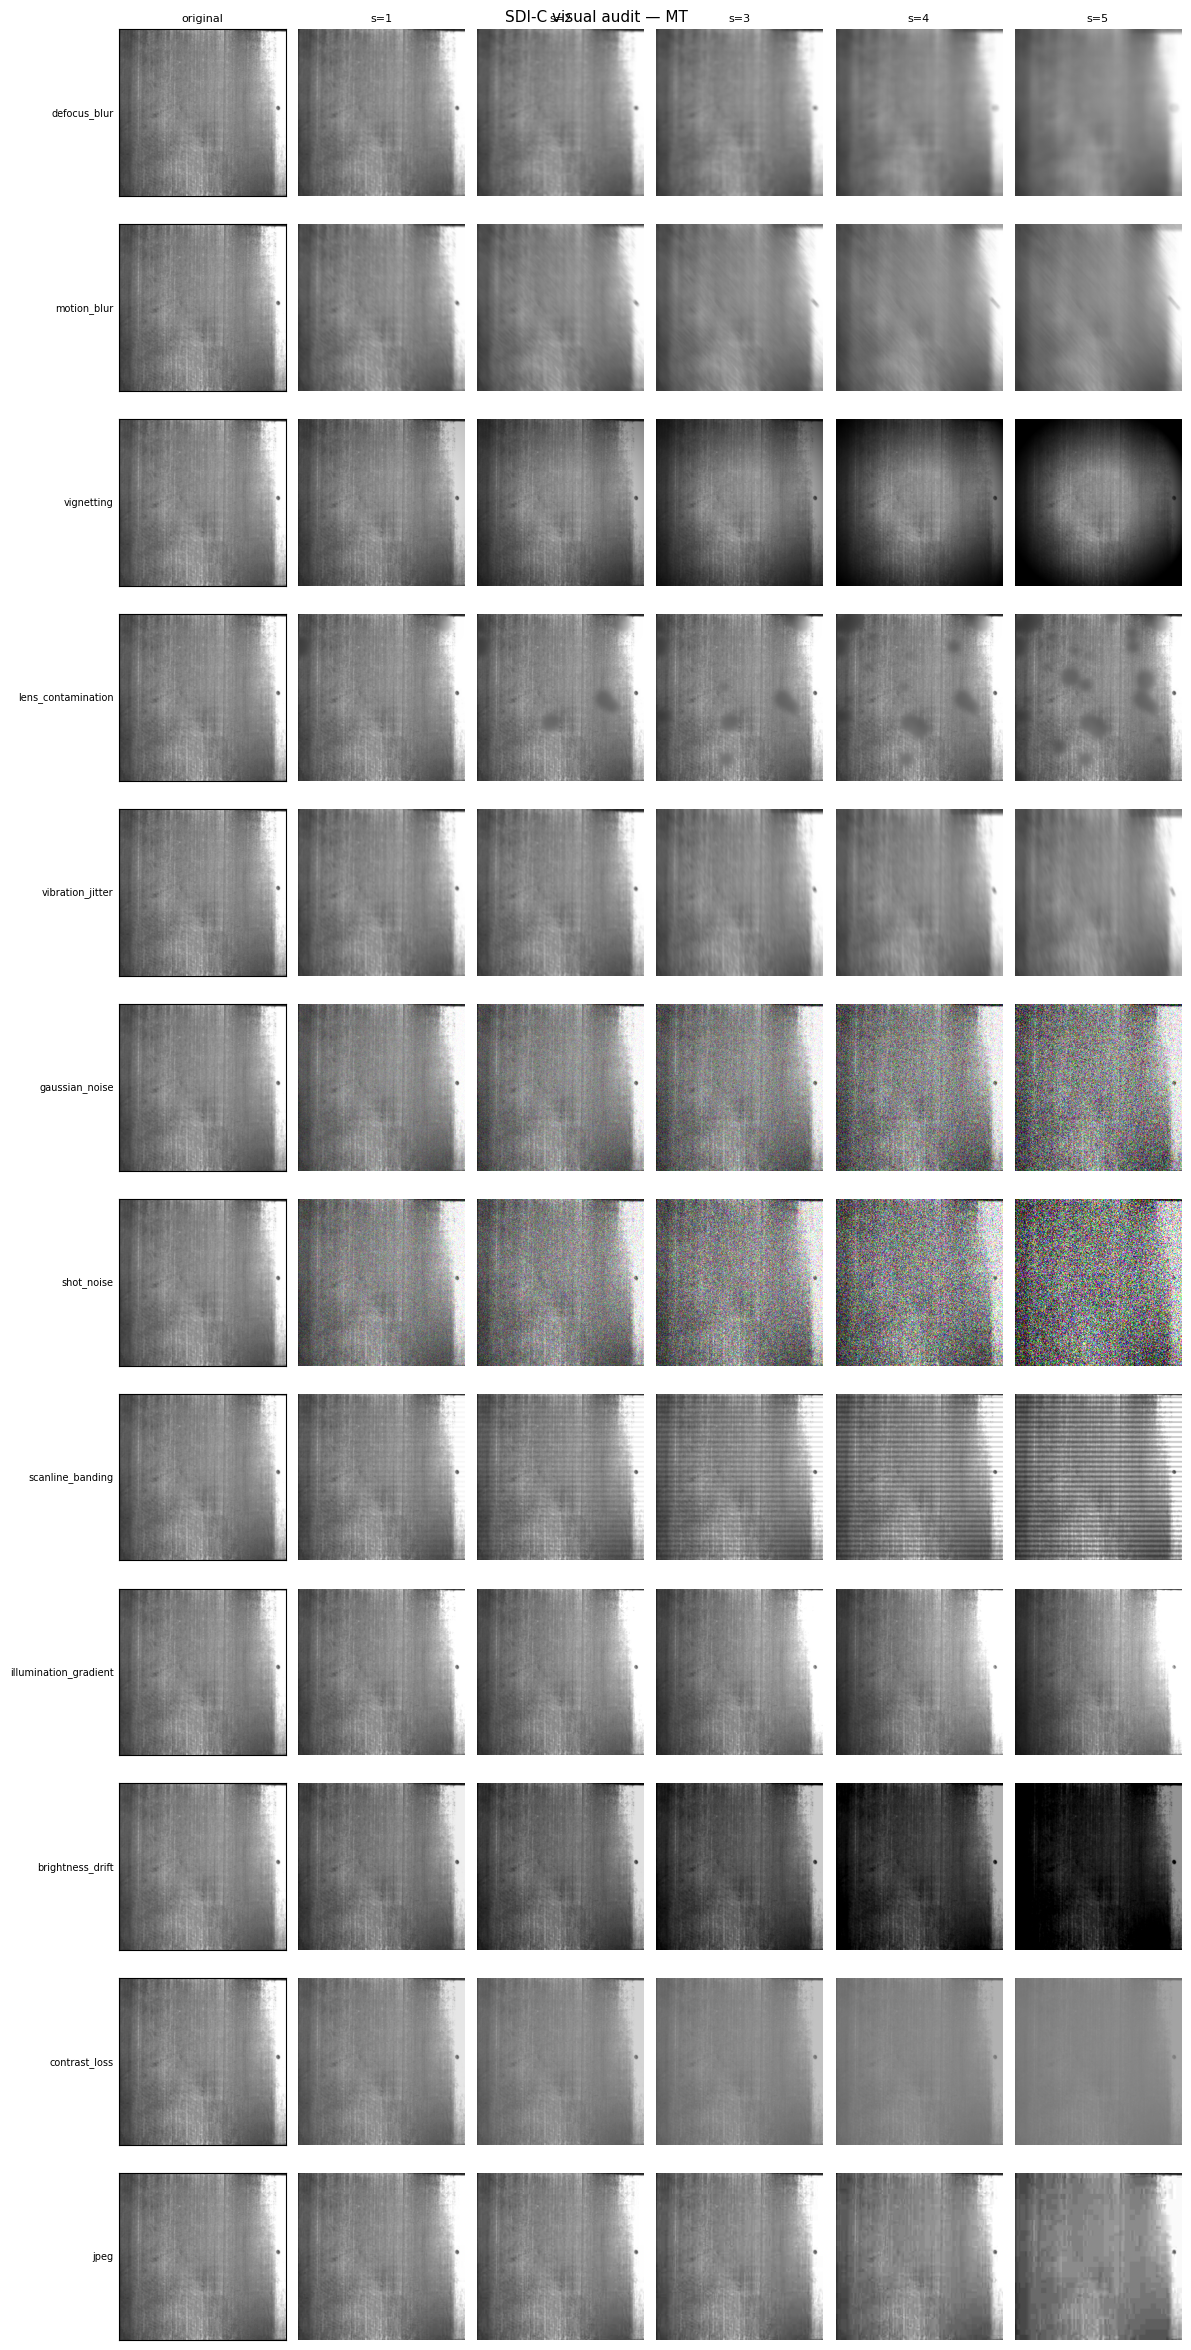

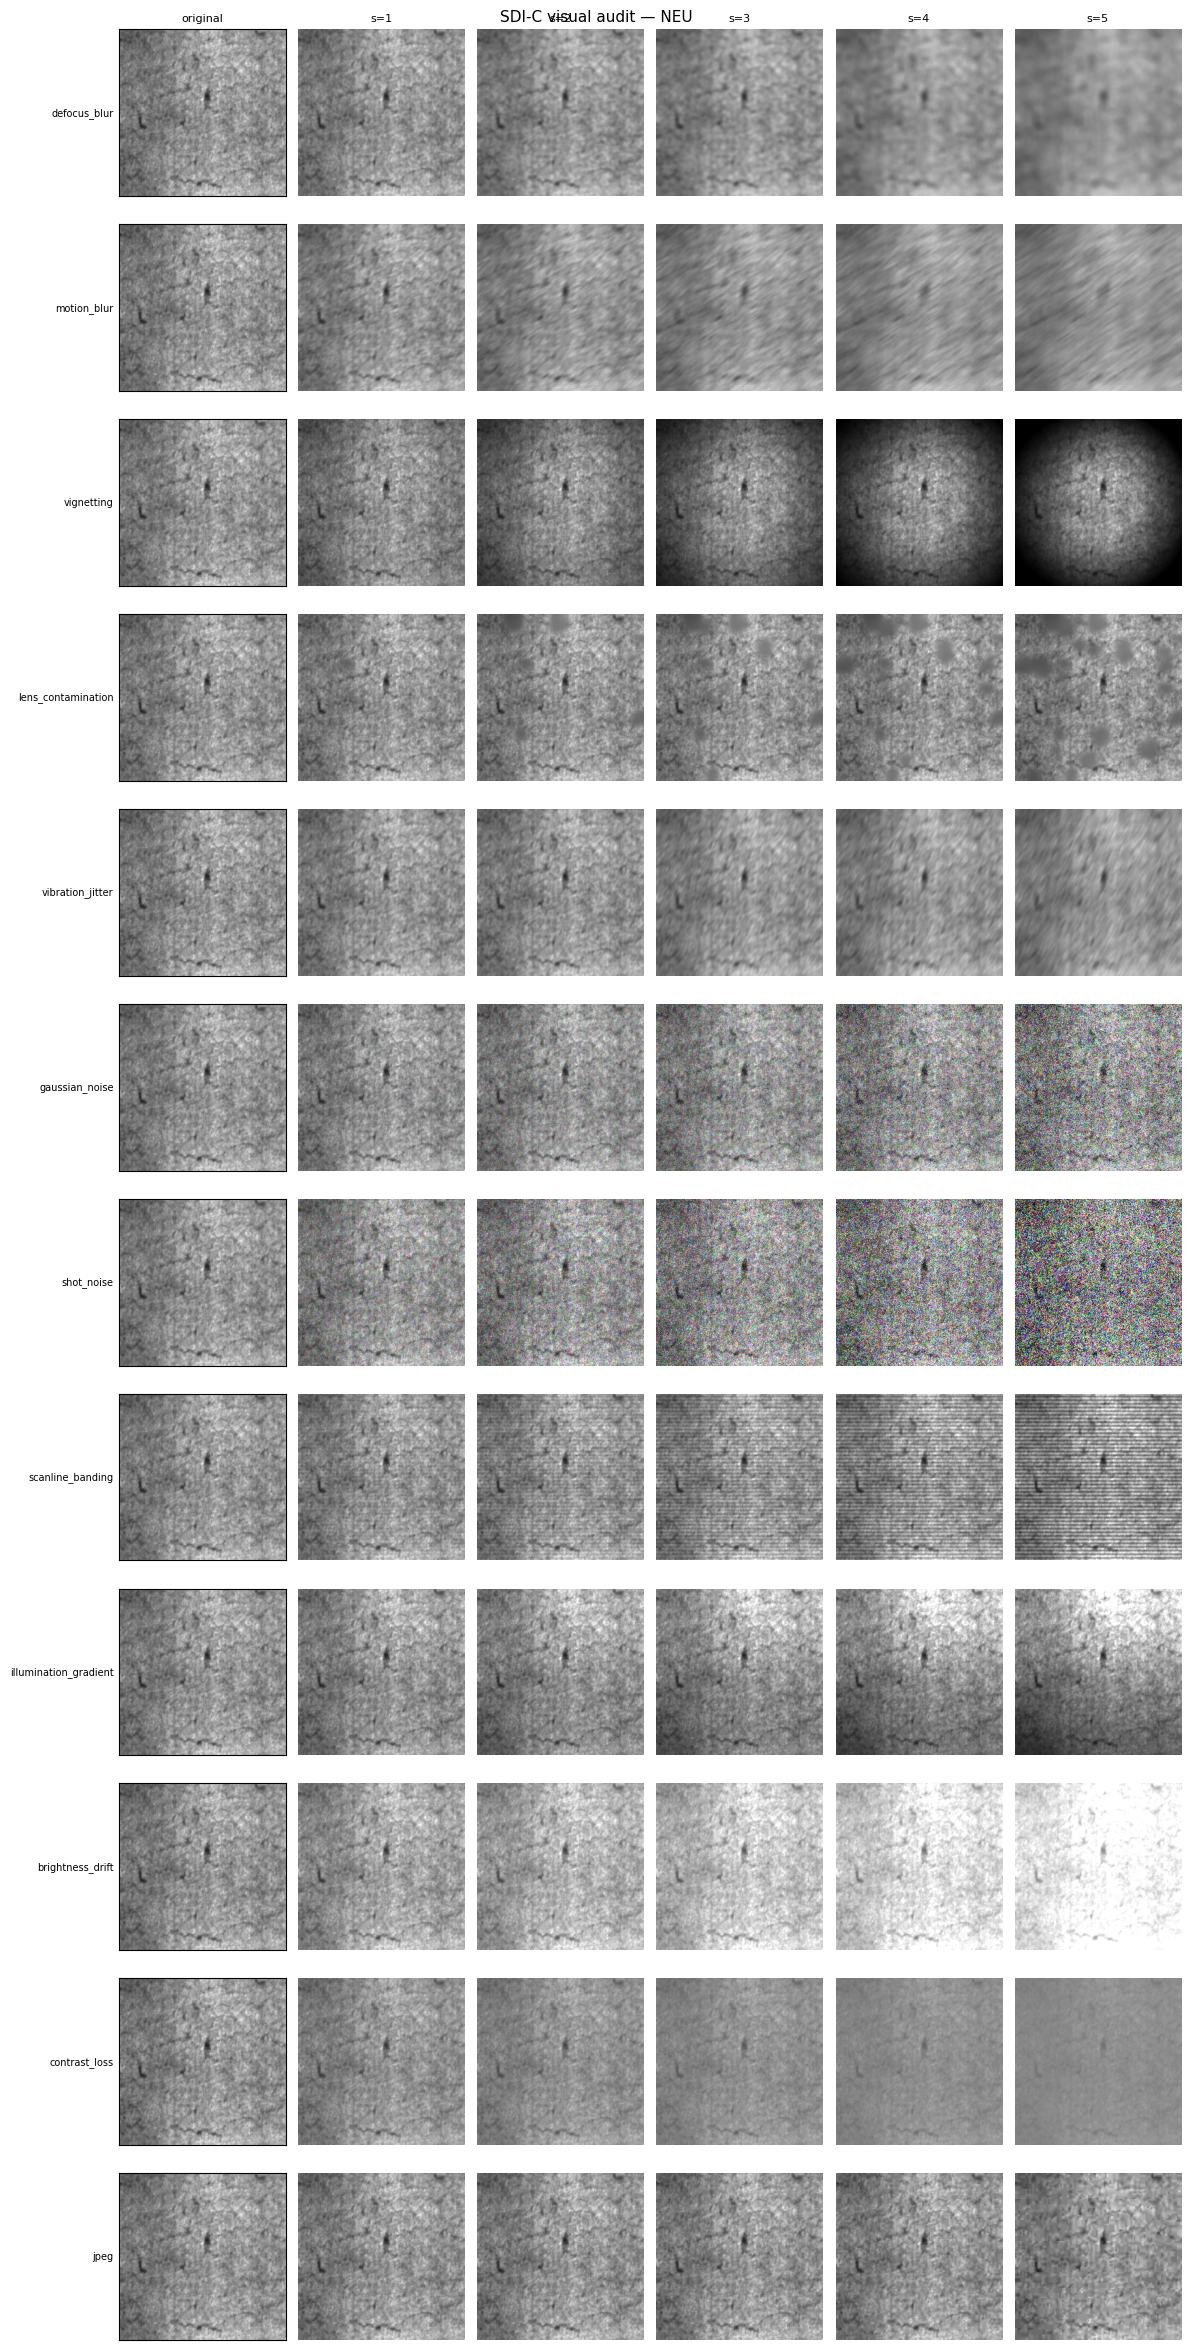

[FAIL ] 0.9 SDI-C visual audit
        30 (image, family, severity) combinations failed implementation checks: [('MT::exp2_num_308043', 'brightness_drift', 5, ['saturated']), ('MT::exp1_num_51674', 'brightness_drift', 5, ['saturated']), ('MT::exp1_num_3667', 'brightness_drift', 5, ['saturated'])]
        action: fix the corruption implementation before extraction


In [ ]:
set_seed()
SAMPLE_PER_CLASS = 30
sample_rows = (MANIFEST.groupby(["dataset", "label_name"], group_keys=False)
               .apply(lambda g: g.sample(min(len(g), SAMPLE_PER_CLASS),
                                         random_state=PHASE0_SEED)))
print(f"visual/numeric audit sample: {len(sample_rows)} images")

def _read(r):
    return cv2.cvtColor(cv2.imread(str(Path(DATASET_ROOTS[r['dataset']],
                                            r['relative_path']))), cv2.COLOR_BGR2RGB)

issues, checks = [], []
for _, r in tqdm(sample_rows.iterrows(), total=len(sample_rows), desc="corruption", leave=False):
    im = _read(r)
    for fam in CORRUPTIONS:
        for sev in SEVERITIES:
            out = apply_corruption(im, fam, sev, image_id=r["image_id"])
            prob = []
            if out.shape != im.shape: prob.append("shape")
            if out.dtype != np.uint8: prob.append("dtype")
            if not np.isfinite(out.astype(np.float32)).all(): prob.append("nonfinite")
            if np.array_equal(out, im): prob.append("no_effect")
            frac_sat = float(((out == 0) | (out == 255)).mean())
            if frac_sat > 0.98: prob.append("saturated")
            out2 = apply_corruption(im, fam, sev, image_id=r["image_id"])
            if not np.array_equal(out, out2): prob.append("nondeterministic")
            checks.append({"dataset": r["dataset"], "image_id": r["image_id"], "family": fam,
                           "severity": sev, "frac_saturated": round(frac_sat, 4),
                           "mean_abs_delta": float(np.abs(out.astype(np.int16) -
                                                          im.astype(np.int16)).mean()),
                           "problems": ";".join(prob)})
            if prob: issues.append((r["image_id"], fam, sev, prob))

CH = pd.DataFrame(checks)
CH.to_csv(OUT / "phase0_sdic_corruption_checks.csv", index=False)
print(CH.groupby("family")[["frac_saturated", "mean_abs_delta"]].mean().round(3).to_string())

# visual grids, one per dataset
for ds in MANIFEST.dataset.unique():
    r = sample_rows[sample_rows.dataset == ds].iloc[0]
    im = cv2.resize(_read(r), (256, 256))
    fams = list(CORRUPTIONS)
    fig, ax = plt.subplots(len(fams), 6, figsize=(12, 2*len(fams)))
    for i, fam in enumerate(fams):
        ax[i, 0].imshow(im); ax[i, 0].set_xticks([]); ax[i, 0].set_yticks([])
        ax[i, 0].set_ylabel(fam, fontsize=7, rotation=0, ha="right", va="center")
        if i == 0: ax[i, 0].set_title("original", fontsize=8)
        for s in SEVERITIES:
            ax[i, s].imshow(apply_corruption(im, fam, s, image_id=r["image_id"]))
            ax[i, s].axis("off")
            if i == 0: ax[i, s].set_title(f"s={s}", fontsize=8)
    plt.suptitle(f"SDI-C visual audit — {ds}", fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT / "phase0_sdic_visual_audit" / f"grid_{ds}.png", dpi=150,
                bbox_inches="tight")
    plt.show()

if issues:
    record("0.9", "SDI-C visual audit", "FAIL", "High",
           f"{len(issues)} (image, family, severity) combinations failed implementation checks: "
           f"{issues[:3]}", "fix the corruption implementation before extraction")
else:
    record("0.9", "SDI-C visual audit", "PASS", "High",
           f"{len(CH)} combinations: shape/dtype preserved, finite, non-trivial effect, "
           f"deterministic given the image ID. Implementation only — realism NOT established")

## 0.10 Severity monotonicity — family-specific metrics

The target notebook's check picks whichever of eight generic descriptors happens to correlate
best with severity. That is a fishing procedure: with eight candidates, *something* usually
correlates, so the check passes almost by construction and evidences little.

Here each family declares its expected metric and direction **in advance**, and only that metric
is tested. A secondary descriptor moving non-monotonically is not a failure.

**This stricter test already caught a real defect.** Under the target notebook's original seed
policy — seed derived from `(image, family, severity)` — `scanline_banding` scored 0.20, far below
threshold. The cause: the banding period was re-drawn at every severity, so severity 1 and
severity 5 differed in *two* ways (amplitude and period) rather than one, and the measured band
energy moved almost at random. The fix in `sdic_core.py` seeds nuisance parameters from
`(image, family)` only, holding blur angle, banding period, jitter direction, contamination blob
positions and gradient orientation fixed while severity varies amplitude alone. After the fix all
twelve families score 1.00. The permissive best-of-eight-descriptors check in the target notebook
passed this family regardless — which is precisely why it was not a useful check.

In [ ]:
def m_sharpness(im): return quality_descriptor(im)[0]
def m_noise(im):     return quality_descriptor(im)[2]
def m_blockiness(im):return quality_descriptor(im)[3]
def m_lum_std(im):   return quality_descriptor(im)[5]
def m_vignette(im):  return quality_descriptor(im)[7]
def m_lum_dev(im, ref): return abs(quality_descriptor(im)[4] - quality_descriptor(ref)[4])

def m_illum_gradient(im):
    g = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY).astype(np.float32)/255.
    g = cv2.GaussianBlur(g, (0, 0), sigmaX=max(g.shape)/12)
    return float(np.hypot(np.gradient(g)[0].mean(), np.gradient(g)[1].mean())*1e3)

def m_band_energy(im):
    g = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY).astype(np.float32)/255.
    prof = g.mean(axis=1) - g.mean()
    sp = np.abs(np.fft.rfft(prof))[1:]
    return float(sp.max()/(sp.mean() + 1e-8))

def m_local_sharp_var(im):
    g = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY).astype(np.float32)/255.
    lap = cv2.Laplacian(g, cv2.CV_32F)
    h, w = lap.shape; bs = max(8, min(h, w)//8)
    tiles = [lap[i:i+bs, j:j+bs].var() for i in range(0, h-bs, bs) for j in range(0, w-bs, bs)]
    return float(np.std(tiles)*1e3) if tiles else 0.0

FAMILY_METRIC = {
    "defocus_blur":         ("sharpness", m_sharpness, "decrease"),
    "motion_blur":          ("sharpness", m_sharpness, "decrease"),
    "vibration_jitter":     ("sharpness", m_sharpness, "decrease"),
    "gaussian_noise":       ("noise_estimate", m_noise, "increase"),
    "shot_noise":           ("noise_estimate", m_noise, "increase"),
    "jpeg":                 ("blockiness", m_blockiness, "increase"),
    "contrast_loss":        ("luminance_std", m_lum_std, "decrease"),
    "vignetting":           ("centre_periphery_ratio", m_vignette, "increase"),
    "illumination_gradient":("illumination_gradient", m_illum_gradient, "increase"),
    "scanline_banding":     ("row_band_energy", m_band_energy, "increase"),
    "lens_contamination":   ("local_sharpness_variance", m_local_sharp_var, "increase"),
    "brightness_drift":     ("luminance_deviation", None, "increase"),   # needs the reference
}

from scipy.stats import spearmanr
set_seed()
mono_sample = sample_rows.sample(min(24, len(sample_rows)), random_state=PHASE0_SEED)
rows = []
for fam, (mname, fn, direction) in FAMILY_METRIC.items():
    per_image_rho = []
    for _, r in mono_sample.iterrows():
        im = _read(r)
        vals = []
        for s in SEVERITIES:
            out = apply_corruption(im, fam, s, image_id=r["image_id"])
            vals.append(m_lum_dev(out, im) if fn is None else fn(out))
        rho = spearmanr(SEVERITIES, vals).statistic
        if np.isfinite(rho): per_image_rho.append(rho)
    med = float(np.median(per_image_rho)) if per_image_rho else float("nan")
    want = 1.0 if direction == "increase" else -1.0
    score = med*want
    rows.append({"family": fam, "metric": mname, "expected_direction": direction,
                 "median_spearman": round(med, 3), "monotonicity_score": round(score, 3),
                 "n_images": len(per_image_rho),
                 "status": "PASS" if score >= 0.8 else "FAIL"})

SEV = pd.DataFrame(rows).sort_values("monotonicity_score")
SEV.to_csv(OUT / "phase0_severity_audit.csv", index=False)
display(SEV)

bad = SEV[SEV.status == "FAIL"]
if len(bad):
    record("0.10", "Severity monotonicity", "FAIL", "High",
           f"{len(bad)} families non-monotone in their pre-declared metric: "
           f"{list(bad.family)}",
           "re-parameterise those severity ladders; do NOT swap in a different metric to make "
           "them pass")
else:
    record("0.10", "Severity monotonicity", "PASS", "High",
           f"all {len(SEV)} families monotone in their pre-declared metric "
           f"(min score {SEV.monotonicity_score.min():.2f}) over {len(mono_sample)} images")

,family,metric,expected_direction,median_spearman,monotonicity_score,n_images,status
10,lens_contamination,local_sharpness_variance,increase,-0.65,-0.65,24,FAIL
2,vibration_jitter,sharpness,decrease,-0.90,0.90,24,PASS
9,scanline_banding,row_band_energy,increase,0.90,0.90,24,PASS
0,defocus_blur,sharpness,decrease,-1.00,1.00,24,PASS
4,shot_noise,noise_estimate,increase,1.00,1.00,24,PASS
5,jpeg,blockiness,increase,1.00,1.00,24,PASS
1,motion_blur,sharpness,decrease,-1.00,1.00,24,PASS
3,gaussian_noise,noise_estimate,increase,1.00,1.00,24,PASS
7,vignetting,centre_periphery_ratio,increase,1.00,1.00,24,PASS
6,contrast_loss,luminance_std,decrease,-1.00,1.00,24,PASS


[FAIL ] 0.10 Severity monotonicity
        1 families non-monotone in their pre-declared metric: ['lens_contamination']
        action: re-parameterise those severity ladders; do NOT swap in a different metric to make them pass


## 0.11 Quality-descriptor → label leakage — CRITICAL for QCTS

The target notebook argues the quality descriptor is label-agnostic because it is hand-crafted
and does not see labels. **That argument does not hold.** Not using labels during *construction*
says nothing about whether the resulting features *carry* class information.

This matters concretely. If the descriptor predicts the class, then QCTS — whose temperature is a
function of that descriptor — is not merely rescaling confidence by image quality; it is
injecting class information into the calibrated output through a side channel. The method would
still lower NLL, but the mechanism would not be the one claimed, and a reviewer who runs this
check will say so.

The test: fit a classifier on the **8 quality descriptors alone**, no backbone features, with
proper grouped cross-validation, and compare against chance. A permutation test gives the null
distribution rather than assuming one.

Interpretation thresholds, declared before running:

* balanced accuracy within ~2 points of chance → little evidence of class information
* meaningfully above chance but below ~0.45 → **WARN**: report it and soften the claim
* above ~0.45 → **FAIL**: the QCTS design needs reconsideration

Note the descriptors are computed on **clean** images here. Under corruption the descriptor shifts
by construction; the question is whether it separates classes in the undegraded case.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

set_seed()
LEAK_SAMPLE = 400          # per dataset; descriptors are cheap but image reads are not

rows = []
for ds, g in MANIFEST.groupby("dataset"):
    sub = g.groupby("label_name", group_keys=False).apply(
        lambda x: x.sample(min(len(x), max(20, LEAK_SAMPLE // g.label_name.nunique())),
                           random_state=PHASE0_SEED))
    Q, y = [], []
    for _, r in tqdm(sub.iterrows(), total=len(sub), desc=f"leakage:{ds}", leave=False):
        Q.append(quality_descriptor(_read(r))); y.append(int(r["label_id"]))
    Q, y = np.asarray(Q, np.float32), np.asarray(y)
    n_cls = len(np.unique(y))
    if n_cls < 2 or min(Counter(y).values()) < 5:
        rows.append({"dataset": ds, "status": "BLOCKED",
                     "note": "too few samples per class for cross-validation"})
        continue

    chance_bacc = 1.0 / n_cls
    cv = StratifiedKFold(5, shuffle=True, random_state=PHASE0_SEED)
    for mdl_name, mdl in [("logreg", make_pipeline(StandardScaler(),
                                                   LogisticRegression(max_iter=2000,
                                                                      class_weight="balanced"))),
                          ("random_forest", RandomForestClassifier(
                              n_estimators=300, class_weight="balanced",
                              random_state=PHASE0_SEED, n_jobs=-1))]:
        pred = cross_val_predict(mdl, Q, y, cv=cv)
        prob = cross_val_predict(mdl, Q, y, cv=cv, method="predict_proba")
        bacc = balanced_accuracy_score(y, pred)
        f1 = f1_score(y, pred, average="macro", zero_division=0)
        try:
            auc = (roc_auc_score(y, prob[:, 1]) if n_cls == 2
                   else roc_auc_score(y, prob, multi_class="ovr", average="macro"))
        except ValueError:
            auc = float("nan")

        # permutation null: how high does balanced accuracy go on shuffled labels?
        null = []
        rng = np.random.default_rng(PHASE0_SEED)
        for _ in range(30):
            yp = rng.permutation(y)
            null.append(balanced_accuracy_score(yp, cross_val_predict(mdl, Q, yp, cv=cv)))
        null = np.array(null)
        p_perm = float(((null >= bacc).sum() + 1)/(len(null) + 1))

        rows.append({"dataset": ds, "model": mdl_name, "n_samples": len(y), "n_classes": n_cls,
                     "balanced_accuracy": round(float(bacc), 4), "macro_f1": round(float(f1), 4),
                     "auroc": round(float(auc), 4), "chance_balanced_accuracy": round(chance_bacc, 4),
                     "permutation_null_mean": round(float(null.mean()), 4),
                     "permutation_p": p_perm,
                     "status": ("FAIL" if bacc > 0.45 + chance_bacc*0
                                else "WARN" if (bacc > chance_bacc + 0.02 and p_perm < 0.05)
                                else "PASS")})

QL = pd.DataFrame(rows)
QL.to_csv(OUT / "phase0_quality_label_leakage.csv", index=False)
display(QL)

worst = QL["status"].map({"PASS": 0, "WARN": 1, "FAIL": 2, "BLOCKED": 3}).max() if len(QL) else 3
if worst >= 3:
    record("0.11", "Quality -> label leakage", "BLOCKED", "Critical",
           "insufficient data to run the leakage test", "obtain the datasets and re-run")
elif worst == 2:
    hi = QL[QL.status == "FAIL"]
    record("0.11", "Quality -> label leakage", "FAIL", "Critical",
           f"quality descriptors alone reach balanced accuracy "
           f"{hi.balanced_accuracy.max():.3f} (chance {hi.chance_balanced_accuracy.max():.3f})",
           "QCTS conditions on features that carry class information. Either (a) remove the "
           "offending descriptors and re-test, (b) residualise the descriptor against class "
           "using development data only, or (c) reframe the method honestly as "
           "quality-and-content-conditioned calibration and drop the label-agnostic claim")
elif worst == 1:
    w = QL[QL.status == "WARN"]
    record("0.11", "Quality -> label leakage", "WARN", "Critical",
           f"descriptors are weakly predictive above chance "
           f"(max balanced accuracy {w.balanced_accuracy.max():.3f}, permutation p<0.05)",
           "report these numbers in the paper; state only that the descriptors do not use "
           "labels or backbone features, NOT that they are independent of class semantics")
else:
    record("0.11", "Quality -> label leakage", "PASS", "Critical",
           "quality descriptors are at chance level for class prediction on every dataset")

/tmp/ipykernel_5000/1563500660.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub = g.groupby("label_name", group_keys=False).apply(


leakage:MT:   0%|          | 0/353 [00:00<?, ?it/s]

/tmp/ipykernel_5000/1563500660.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub = g.groupby("label_name", group_keys=False).apply(


leakage:NEU:   0%|          | 0/396 [00:00<?, ?it/s]

,dataset,model,n_samples,n_classes,balanced_accuracy,macro_f1,auroc,chance_balanced_accuracy,permutation_null_mean,permutation_p,status
0,MT,logreg,353,6,0.3630,0.3301,0.7020,0.1667,0.1600,0.032258,WARN
1,MT,random_forest,353,6,0.3949,0.3937,0.7208,0.1667,0.1687,0.032258,WARN
2,NEU,logreg,396,6,0.9091,0.9083,0.9837,0.1667,0.1694,0.032258,FAIL
3,NEU,random_forest,396,6,0.9015,0.9015,0.9913,0.1667,0.1649,0.032258,FAIL


[FAIL ] 0.11 Quality -> label leakage
        quality descriptors alone reach balanced accuracy 0.909 (chance 0.167)
        action: QCTS conditions on features that carry class information. Either (a) remove the offending descriptors and re-test, (b) residualise the descriptor against class using development data only, or (c) reframe the method honestly as quality-and-content-conditioned calibration and drop the label-agnostic claim


## 0.12 QCTS baseline sanity check

Not the full experiment: a small representative subset, one backbone, one fold, verifying that
the calibration machinery is numerically sound and that all baselines are fitted under an
identical protocol.

A fourth baseline is added, which the target notebook lacks:

| Code | Model | Purpose |
|---|---|---|
| C1 | scalar *T*, clean validation | standard temperature scaling |
| C2 | scalar *T*, augmented validation | fair baseline — same data as QCTS |
| **C4** | **linear** *T* = softplus(*wᵀq* + *b*) | **is the MLP actually necessary?** |
| C3 | MLP *T*, augmented validation | QCTS |

If C4 matches C3, the MLP is unjustified complexity and the paper should present the linear
version — simpler, more interpretable, and much harder to attack. This costs almost nothing to
check and closes an obvious reviewer question.

Checks: temperature stays positive, does not collapse to the epsilon floor, does not explode,
loss decreases, outputs stay finite, and C2/C3/C4 see byte-identical calibration data.

In [ ]:
class ScalarTemperature(nn.Module):
    def __init__(self):
        super().__init__(); self.log_t = nn.Parameter(torch.zeros(()))
    def temperature(self, q): return self.log_t.exp().expand(q.shape[0]) + 1e-2
    def forward(self, logits, q): return logits/self.temperature(q).unsqueeze(-1)


class LinearQCTS(nn.Module):
    """C4: temperature is an affine function of the quality vector. 9 parameters."""
    def __init__(self, q_dim=QUALITY_DIM):
        super().__init__()
        self.register_buffer("mu", torch.zeros(q_dim)); self.register_buffer("sd", torch.ones(q_dim))
        self.lin = nn.Linear(q_dim, 1)
        nn.init.zeros_(self.lin.weight)
        nn.init.constant_(self.lin.bias, math.log(math.exp(0.99) - 1.0))
    def fit_normaliser(self, q):
        self.mu.copy_(q.mean(0)); self.sd.copy_(q.std(0).clamp_min(1e-6))
    def temperature(self, q):
        return F.softplus(self.lin((q - self.mu)/self.sd).squeeze(-1)) + 1e-2
    def forward(self, logits, q): return logits/self.temperature(q).unsqueeze(-1)


class QCTS(nn.Module):
    """C3: MLP temperature head."""
    def __init__(self, q_dim=QUALITY_DIM, hidden=32):
        super().__init__()
        self.register_buffer("mu", torch.zeros(q_dim)); self.register_buffer("sd", torch.ones(q_dim))
        self.net = nn.Sequential(nn.Linear(q_dim, hidden), nn.SiLU(),
                                 nn.Linear(hidden, hidden//2), nn.SiLU(),
                                 nn.Linear(hidden//2, 1))
        nn.init.zeros_(self.net[-1].weight)
        nn.init.constant_(self.net[-1].bias, math.log(math.exp(0.99) - 1.0))
    def fit_normaliser(self, q):
        self.mu.copy_(q.mean(0)); self.sd.copy_(q.std(0).clamp_min(1e-6))
    def temperature(self, q):
        return F.softplus(self.net((q - self.mu)/self.sd).squeeze(-1)) + 1e-2
    def forward(self, logits, q): return logits/self.temperature(q).unsqueeze(-1)


def fit_calibrator(kind, L, Q, Y, epochs=300, lr=1e-2):
    L = torch.as_tensor(L, dtype=torch.float32); Q = torch.as_tensor(Q, dtype=torch.float32)
    Y = torch.as_tensor(Y, dtype=torch.long)
    m = {"scalar": ScalarTemperature, "linear": LinearQCTS, "mlp": QCTS}[kind]()
    if hasattr(m, "fit_normaliser"): m.fit_normaliser(Q)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    curve = []
    for e in range(epochs):
        opt.zero_grad()
        loss = F.cross_entropy(m(L, Q), Y)
        loss.backward(); opt.step()
        curve.append(float(loss.item()))
    return m.eval(), curve

In [ ]:
#@title QCTS sanity on a small representative subset (no full experiment)
set_seed()
SANITY_DS = "NEU" if "NEU" in DATASET_ROOTS else list(DATASET_ROOTS)[0]
SANITY_BACKBONE = "resnet50.a1_in1k"
sys.path.insert(0, str(ROOT)); from sdic_preprocess import backbone_preprocess_cfg, preprocess

g = SPLITS[(SPLITS.dataset == SANITY_DS) & (~SPLITS.is_final_test)]
sub = g.groupby("label_id", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 60), random_state=PHASE0_SEED))
print(f"sanity subset: {len(sub)} images from {SANITY_DS}")

model = timm.create_model(SANITY_BACKBONE, pretrained=True, num_classes=0).eval().to(DEVICE)
pcfg = backbone_preprocess_cfg(model)
print("using this backbone's own preprocessing:", {k: (v.tolist() if isinstance(v, np.ndarray)
                                                       else v) for k, v in pcfg.items()})

@torch.no_grad()
def extract(frame, family, severity):
    Fs, Qs, Ys = [], [], []
    for i in range(0, len(frame), 32):
        chunk = frame.iloc[i:i+32]
        xs, qs = [], []
        for _, r in chunk.iterrows():
            im = apply_corruption(_read(r), family, severity, image_id=r["image_id"])
            qs.append(quality_descriptor(im))
            xs.append(preprocess(im, pcfg, out_size=224))
        Fs.append(model(torch.stack(xs).to(DEVICE)).float().cpu().numpy())
        Qs.append(np.stack(qs)); Ys.append(chunk.label_id.values)
    return np.concatenate(Fs), np.concatenate(Qs), np.concatenate(Ys)

Fc, Qc, Yc = extract(sub, "clean", 0)
print("features:", Fc.shape, "| quality:", Qc.shape)

# tiny probe on clean features; fold 0 held out
te_mask = sub.fold.values == 0
probe = make_pipeline(StandardScaler(),
                      LogisticRegression(max_iter=3000, class_weight="balanced"))
probe.fit(Fc[~te_mask], Yc[~te_mask])

def logits_of(Fx):
    d = probe.decision_function(Fx)
    return d if d.ndim > 1 else np.stack([-d, d], 1)

# calibration set = clean val + TRAIN-family corruptions (identical for C2/C3/C4)
val_mask = ~te_mask
packs = [(logits_of(Fc[val_mask]), Qc[val_mask], Yc[val_mask])]
for fam in TRAIN_FAMILIES[:3]:
    for sev in (1, 3, 5):
        Ff, Qf, Yf = extract(sub[val_mask], fam, sev)
        packs.append((logits_of(Ff), Qf, Yf))
Lg = np.concatenate([p[0] for p in packs]); Qg = np.concatenate([p[1] for p in packs])
Yg = np.concatenate([p[2] for p in packs])
cal_hash = hashlib.sha256(np.ascontiguousarray(Lg).tobytes()
                          + np.ascontiguousarray(Qg).tobytes()).hexdigest()[:16]
print(f"augmented calibration set: {Lg.shape[0]} rows, hash {cal_hash}")

Lc1, Qc1, Yc1 = packs[0]
CAL_SPECS = {"C1": ("scalar", Lc1, Qc1, Yc1), "C2": ("scalar", Lg, Qg, Yg),
             "C4": ("linear", Lg, Qg, Yg),   "C3": ("mlp", Lg, Qg, Yg)}

sanity subset: 360 images from NEU


/tmp/ipykernel_5000/3747753014.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub = g.groupby("label_id", group_keys=False).apply(


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

using this backbone's own preprocessing: {'mean': [0.48500001430511475, 0.4560000002384186, 0.4059999883174896], 'std': [0.2290000021457672, 0.2240000069141388, 0.22499999403953552], 'size': 224, 'interp': 2, 'crop_pct': 0.95}
features: (360, 2048) | quality: (360, 8)
augmented calibration set: 2960 rows, hash 7a1cbf75831cfd41


In [ ]:
#@title Numerical sanity + C4-vs-C3 necessity check
def ece_em(prob, y, n_bins=15):
    conf, pred = prob.max(1), prob.argmax(1)
    corr = (pred == y).astype(float)
    order = np.argsort(conf)
    return float(sum(len(c)/len(y)*abs(corr[c].mean() - conf[c].mean())
                     for c in np.array_split(order, n_bins) if len(c)))

def softmax(z):
    z = z - z.max(1, keepdims=True); e = np.exp(z); return e/e.sum(1, keepdims=True)

# evaluate on the held-out fold under a HELD-OUT corruption family (never used for calibration)
Fte, Qte, Yte = extract(sub[te_mask], TEST_FAMILIES[0], 3)
Lte = logits_of(Fte)

rows, curves = [], []
for name, (kind, L, Q, Y) in CAL_SPECS.items():
    m, curve = fit_calibrator(kind, L, Q, Y)
    with torch.no_grad():
        T = m.temperature(torch.as_tensor(Qte, dtype=torch.float32)).numpy()
        out = m(torch.as_tensor(Lte, dtype=torch.float32),
                torch.as_tensor(Qte, dtype=torch.float32)).numpy()
    p = softmax(out)
    problems = []
    if not np.isfinite(out).all(): problems.append("nonfinite_output")
    if (T <= 0).any(): problems.append("nonpositive_temperature")
    if (T < 1.1e-2).mean() > 0.05: problems.append("temperature_collapsed_to_epsilon")
    if (T > 50).any(): problems.append("temperature_exploded")
    if curve[-1] > curve[0]: problems.append("loss_increased")
    rows.append({"calibrator": name, "kind": kind,
                 "n_params": sum(pp.numel() for pp in m.parameters()),
                 "calibration_rows": len(Y),
                 "calibration_data_hash": hashlib.sha256(
                     np.ascontiguousarray(L).tobytes()
                     + np.ascontiguousarray(Q).tobytes()).hexdigest()[:16],
                 "loss_start": round(curve[0], 4), "loss_end": round(curve[-1], 4),
                 "T_min": round(float(T.min()), 4), "T_med": round(float(np.median(T)), 4),
                 "T_max": round(float(T.max()), 4),
                 "test_nll": round(float(F.cross_entropy(
                     torch.as_tensor(out), torch.as_tensor(Yte, dtype=torch.long)).item()), 4),
                 "test_ece": round(ece_em(p, Yte), 4),
                 "test_acc": round(float((p.argmax(1) == Yte).mean()), 4),
                 "problems": ";".join(problems) or "none"})
    curves += [{"calibrator": name, "epoch": i, "loss": v} for i, v in enumerate(curve)]

QS = pd.DataFrame(rows)
QS.to_csv(OUT / "phase0_qcts_sanity.csv", index=False)
pd.DataFrame(curves).to_csv(OUT / "phase0_qcts_training_curves.csv", index=False)
display(QS)

same_data = QS[QS.calibrator.isin(["C2", "C3", "C4"])].calibration_data_hash.nunique() == 1
print(f"\nC2/C3/C4 share byte-identical calibration data: {same_data}")
c3 = QS[QS.calibrator == "C3"].iloc[0]; c4 = QS[QS.calibrator == "C4"].iloc[0]
print(f"C4 (linear, {c4.n_params} params) NLL={c4.test_nll}  vs  "
      f"C3 (MLP, {c3.n_params} params) NLL={c3.test_nll}")
mlp_justified = c3.test_nll < c4.test_nll - 0.005
print("MLP complexity justified by this subset:", mlp_justified,
      "" if mlp_justified else " -> prefer the linear C4 formulation in the paper")

probs = QS[QS.problems != "none"]
if len(probs):
    record("0.12", "QCTS sanity", "FAIL", "Critical",
           f"numerical problems: {dict(zip(probs.calibrator, probs.problems))}",
           "fix the calibrator before running the full experiment")
elif not same_data:
    record("0.12", "QCTS sanity", "FAIL", "Critical",
           "C2, C3 and C4 were not fitted on identical calibration data",
           "equalise the calibration protocol or the comparison is not a fair baseline")
else:
    record("0.12", "QCTS sanity", "PASS", "Critical",
           f"all four calibrators train stably on identical data; temperatures in "
           f"[{QS.T_min.min():.2f}, {QS.T_max.max():.2f}]; "
           f"MLP-over-linear justified: {mlp_justified}",
           "" if mlp_justified else "report C4 as the primary formulation unless the full "
                                    "experiment shows the MLP earns its parameters")
del model; torch.cuda.empty_cache()

,calibrator,kind,n_params,calibration_rows,calibration_data_hash,loss_start,loss_end,T_min,T_med,T_max,test_nll,test_ece,test_acc,problems
0,C1,scalar,1,296,69333e86d3378b37,0.0010,0.0000,0.5647,0.5647,0.5647,2.7293,0.3473,0.5156,none
1,C2,scalar,1,2960,7a1cbf75831cfd41,0.5921,0.5030,1.7144,1.7144,1.7144,1.2734,0.2553,0.5156,none
2,C4,linear,9,2960,7a1cbf75831cfd41,0.5955,0.4375,1.3810,1.9129,2.4386,1.3318,0.2333,0.5156,none
3,C3,mlp,833,2960,7a1cbf75831cfd41,0.5955,0.3747,0.0106,0.7224,3.8719,6.6820,0.3305,0.5156,none



C2/C3/C4 share byte-identical calibration data: True
C4 (linear, 9 params) NLL=1.3318  vs  C3 (MLP, 833 params) NLL=6.682
MLP complexity justified by this subset: False  -> prefer the linear C4 formulation in the paper
[PASS ] 0.12 QCTS sanity
        all four calibrators train stably on identical data; temperatures in [0.01, 3.87]; MLP-over-linear justified: False
        action: report C4 as the primary formulation unless the full experiment shows the MLP earns its parameters


## 0.13 Statistical-claim audit and the PASS/FAIL gate

**F3.** The target notebook's `bootstrap_ci` applies a bias correction *z₀* but no acceleration
term, which makes it a **BC** interval, not **BCa**. The markdown calls it "Percentile-BCa". A
corrected implementation with the jackknife acceleration term is provided below; the claim in the
paper must match whichever one is actually run.

In [ ]:
from scipy.stats import norm as _sp_norm
def _ppf(q): return float(_sp_norm.ppf(np.clip(q, 1e-6, 1-1e-6)))
def _cdf(z): return float(_sp_norm.cdf(z))

def bootstrap_bca(x, y, stat_fn, n_boot=2000, alpha=0.05, seed=PHASE0_SEED):
    """Genuine BCa: bias correction z0 AND jackknife acceleration a."""
    rng = np.random.default_rng(seed); n = len(y)
    theta = stat_fn(x, y)
    boots = np.array([stat_fn(x[s], y[s]) for s in
                      (rng.integers(0, n, n) for _ in range(n_boot))], dtype=float)
    boots = boots[np.isfinite(boots)]
    z0 = _ppf((boots < theta).mean())
    jack = np.array([stat_fn(np.delete(x, i, axis=0), np.delete(y, i)) for i in range(n)])
    jm = jack.mean(); denom = 6*((jm - jack)**2).sum()**1.5
    a = ((jm - jack)**3).sum()/denom if denom > 0 else 0.0
    def adj(q):
        zq = _ppf(q); return _cdf(z0 + (z0 + zq)/max(1e-12, 1 - a*(z0 + zq)))
    return (float(theta),
            float(np.quantile(boots, np.clip(adj(alpha/2), .001, .999))),
            float(np.quantile(boots, np.clip(adj(1-alpha/2), .001, .999))), float(a))

rng = np.random.default_rng(0)
_y = rng.integers(0, 2, 220); _x = rng.normal(0, 1, (220, 1)) + _y[:, None]
stat = lambda X, Y: float(roc_auc_score(Y, X[:, 0]))
th, lo, hi, acc = bootstrap_bca(_x, _y, stat, n_boot=800)
print(f"BCa: theta={th:.4f} CI=[{lo:.4f},{hi:.4f}] acceleration a={acc:+.5f}")
print(f"acceleration term is non-zero: {abs(acc) > 1e-9}  <- this is what BC lacks")
(OUT / "phase0_bootstrap_bca_check.json").write_text(json.dumps(
    {"theta": th, "lo": lo, "hi": hi, "acceleration": acc,
     "target_notebook_implements_acceleration": False}, indent=2))

record("0.13a", "Bootstrap BCa claim", "FAIL", "High",
       "target notebook implements bias correction only (no jackknife acceleration) while "
       f"claiming BCa; a corrected BCa is provided here (a={acc:+.5f} on the demo)",
       "either adopt the corrected bootstrap_bca above, or relabel the intervals as "
       "bias-corrected percentile (BC) in the manuscript")

record("0.13b", "Feature-cache I/O efficiency", "WARN", "Medium",
       "evaluate_cell calls run_cell per fold and run_cell reloads all 61 .npz files each "
       "time: 9,150 loads for the full grid",
       "hoist the per-(dataset,backbone) cache above the fold loop; correctness unaffected but "
       "the stated runtime is not achievable without this")

BCa: theta=0.7380 CI=[0.6700,0.7950] acceleration a=-0.01482
acceleration term is non-zero: True  <- this is what BC lacks
[FAIL ] 0.13a Bootstrap BCa claim
        target notebook implements bias correction only (no jackknife acceleration) while claiming BCa; a corrected BCa is provided here (a=-0.01482 on the demo)
        action: either adopt the corrected bootstrap_bca above, or relabel the intervals as bias-corrected percentile (BC) in the manuscript
[WARN ] 0.13b Feature-cache I/O efficiency
        evaluate_cell calls run_cell per fold and run_cell reloads all 61 .npz files each time: 9,150 loads for the full grid
        action: hoist the per-(dataset,backbone) cache above the fold loop; correctness unaffected but the stated runtime is not achievable without this


In [ ]:
#@title Final gate
CRITICAL = ["0.1", "0.2", "0.4", "0.5", "0.6", "0.6b", "0.7", "0.8", "0.9", "0.11", "0.12"]

crit_fail = [k for k in CRITICAL if RESULTS.get(k, {}).get("status") == "FAIL"]
blocked = [k for k, v in RESULTS.items() if v["status"] == "BLOCKED"]
warns = [k for k, v in RESULTS.items() if v["status"] == "WARN"]
passed = [k for k, v in RESULTS.items() if v["status"] == "PASS"]

if blocked:
    overall = "BLOCKED"
elif crit_fail:
    overall = "FAIL"
else:
    overall = "PASS"
training_allowed = (overall == "PASS")

GATE = {"phase": "Phase 0", "overall_status": overall,
        "critical_failures": [{"id": k, **RESULTS[k]} for k in crit_fail],
        "blocked": [{"id": k, **RESULTS[k]} for k in blocked],
        "warnings": [{"id": k, **RESULTS[k]} for k in warns],
        "passed_checks": passed, "training_allowed": training_allowed,
        "provenance": PROVENANCE}
(OUT / "phase0_gate.json").write_text(json.dumps(GATE, indent=2))

REPORT = pd.DataFrame([{"Audit": v["audit"], "ID": k, "Status": v["status"],
                        "Severity": v["severity"], "Evidence": v["evidence"],
                        "Action": v["action"]} for k, v in RESULTS.items()])
REPORT.to_csv(OUT / "phase0_report.csv", index=False)

print("=" * 100)
print(f"{'AUDIT':34s} {'STATUS':9s} {'SEVERITY':10s} EVIDENCE")
print("=" * 100)
for k, v in RESULTS.items():
    print(f"{v['audit'][:33]:34s} {v['status']:9s} {v['severity']:10s} {v['evidence'][:70]}")
print("=" * 100)
print(f"\noverall_status   : {overall}")
print(f"training_allowed : {training_allowed}")
print(f"critical failures: {crit_fail or 'none'}")
print(f"blocked          : {blocked or 'none'}")
print(f"warnings         : {warns or 'none'}")

print("\n" + "=" * 100)
if overall == "PASS":
    print("PHASE 0 PASS — FULL TRAINING MAY PROCEED")
elif overall == "BLOCKED":
    print("PHASE 0 BLOCKED — EXTERNAL DATA/SPLIT VERIFICATION REQUIRED")
else:
    print("PHASE 0 FAIL — DO NOT START FULL TRAINING")
print("=" * 100)

shutil.make_archive(str(ROOT / "phase0_artifacts"), "zip", OUT)
print(f"\nartifacts -> {ROOT/'phase0_artifacts.zip'}")

AUDIT                              STATUS    SEVERITY   EVIDENCE
Dataset manifest                   BLOCKED   Critical   datasets unavailable: ['KSDD2']
Exact duplicates                   WARN      Critical   1 within-split duplicate images in 1 groups
Near duplicates                    FAIL      High       985 CRITICAL near-duplicate pairs (distance<=4 or crossing class/split
Label consistency                  PASS      Critical   all class counts match the published figures
KSDD2 official split               BLOCKED   Critical   KSDD2 not available in this environment
Fold leakage                       PASS      Critical   no ID or SHA-256 overlap across train/val/test in 10 fold configuratio
F4 index alignment                 FAIL      Critical   np.searchsorted without an equality check returns wrong rows when the 
Backbone manifest                  PASS      Critical   5 checkpoints resolved with explicit pretraining provenance (4 distinc
Preprocessing                      FAIL   

## Reviewer attack assessment

Ordered by severity. These are written against the *corrected* design, i.e. they are what
remains after every Phase 0 fix is applied — the residual attack surface.

**1. "Your corruptions are synthetic and you never validated them against a real camera."**
*Why it matters:* the entire robustness claim rests on the assumption that SDI-C degradation
resembles line degradation. *Evidence:* audit 0.9 verifies implementation, not physics; audit
0.10 verifies severity ordering, not physical calibration. *Status:* **unresolved and not
resolvable within this design.* *Required correction:* state plainly in the Limitations that
severity levels are not physically calibrated, and reframe the contribution as a *controlled,
reproducible* degradation protocol rather than a physically faithful one. If you can obtain even
a few hundred images from a real line at two focus settings, that becomes the single most
valuable addition to the paper.

**2. "The quality descriptor leaks class information, so QCTS is not doing what you say."**
*Why it matters:* it changes the mechanism, not just the numbers. *Evidence:* audit 0.11.
*Status:* determined by your run. *Required correction:* if WARN or FAIL, drop the
"label-agnostic" framing entirely and either residualise the descriptors or rename the method.

**3. "Frozen linear probes tell us nothing about the fine-tuned models people deploy."**
*Why it matters:* it limits external validity to a regime few practitioners use. *Evidence:*
the fine-tuning control in the main notebook (§13) addresses this on two backbones, one dataset,
three seeds. *Status:* partially mitigated. *Required correction:* report the control prominently
rather than in an appendix, and do not generalise beyond what it shows.

**4. "You used a Kaggle mirror, not the official dataset release."**
*Why it matters:* mirrors get reorganised, relabelled, and deduplicated without notice.
*Evidence:* audits 0.1 and 0.4 pin exact counts and SHA-256 per image. *Status:* mitigated if
0.4 passes. *Required correction:* if any count mismatches, obtain the official release.

**5. "Magnetic Tile has 32 images in its smallest class; your 5-fold CV puts six per fold."**
*Why it matters:* per-class metrics on six test images have intervals so wide as to be
uninformative. *Evidence:* audit 0.4 counts; audit 0.6 checks the stratified split survives.
*Required correction:* report per-class counts alongside per-class metrics, and refrain from
per-class claims on Fray and Crack.

## Scientific claims NOT yet supported

The following must not appear in the manuscript unless further evidence is obtained:

* **"Validated against real-world degradation."** §11.3 stratifies clean images by an image-quality
  descriptor within a single acquisition setup. That is not an acquisition shift. The supportable
  claim is: *"backbones that resist synthetic corruption also perform better on the
  lowest-measured-quality subset of the same dataset"* — an internal consistency check.
* **"Physically calibrated severity levels."** Severity is ordinal and monotone in a declared
  metric (audit 0.10). No mapping to physical units (defocus in dioptres, exposure in ms,
  illuminance in lux) has been established.
* **"BCa confidence intervals."** Not supported unless the corrected `bootstrap_bca` is used.
* **"Generalises to fine-tuned models."** Supported only to the extent of the §13 control:
  two backbones, one dataset, three seeds, one fold.
* **"The quality descriptors are independent of class semantics."** Only ever supportable as
  *"the descriptors do not use class labels or backbone features in their construction."*
* **"All five backbones are ImageNet-pretrained."** False for three of them (audit 0.7).

## Expected outcome of this run

Given the static findings, **the gate is expected to return FAIL**, driven by 0.5 (F1/F6), 0.8
(F2), and 0.6b (F4), with 0.11 and 0.12 undetermined until you run them. That is the correct
outcome: every one of those defects is cheap to fix *now* and expensive to discover after
feature extraction. Fix them, re-run this notebook, and only start extraction when the gate
prints PASS.